# Data Cleaning

## This Notebook performs data cleaning and processing for financial analysis. 


#### Here's a summary of the main sections:

1. Library Imports: Imports necessary Python libraries for data manipulation, API requests, and analysis.

2. API Key Testing: Provides a function to test the validity of API keys.

3. Stock Data Fetching: Retrieves historical stock data from Polygon.io API.

4. News Data Fetching: Collects news articles related to the stock from Polygon.io API.

5. Other Data Fetching: Gathers other financial data points from Polygon.io API.

6. Interest Rates Data: Fetches federal funds rate data from FRED API.

7. Market Data (SPY): Retrieves S&P 500 (SPY) data for market comparison.

8. Stock Data Processing and Technical Indicators Calculations:
  - Calculates technical indicators for stock data
  - Processes financial ratios and metrics
  
  
9. Financials Data featching: Gathers quarterly financial statements from Alpha Vantage API. 

10. Data Merging: Combines all datasets (stock, news, financials, interest rates, market) into a single DataFrame.

11. Final Data Preparation: Selects relevant columns and saves the final dataset to a CSV file.
    - Output: A CSV file containing comprehensive financial data for the specified stock ticker.


## 1. Library ImportsRetrieve the necessary Packages

In [291]:
# pip install yfinance
# pip install boto3
# pip install pandas matplotlib seaborn wordcloud
# pip install textblob
# pip install requests beautifulsoup4
# pip install sec-edgar-downloader
# pip install edgar
# pip install alpha_vantage

In [31]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from functools import reduce

#Necessary for API calls on Polygon.io & Yahoo finance
import boto3
from botocore.config import Config
import requests
import json
import yfinance as yf


from wordcloud import WordCloud
import plotly.graph_objs as go
import plotly.express as px
from datetime import datetime, timedelta

#Finance Data
import requests
import yfinance as yf

# Web Articles
from bs4 import BeautifulSoup
import time
from requests.exceptions import RequestException
from tqdm import tqdm
from textblob import TextBlob


# Set the display option to show full column length
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

## 2. API Key Testing & Initialize Global Variables
https://polygon.io/knowledge-base/article/how-to-get-started-with-s3

In [60]:
# Define the API key and base URL
api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'
base_url = 'https://api.polygon.io/v2/reference/news'

# Simple function to test the API key
def test_api_key(api_key):
    url = f"{base_url}?ticker=AAPL&limit=1&apiKey={api_key}"
    response = requests.get(url)
    if response.status_code == 401:
        print("Unauthorized request. Please check your API key and permissions.")
    elif response.status_code == 200:
        print("API key is valid.")
    else:
        print(f"Unexpected error: {response.status_code}, {response.text}")

# Test the API key
test_api_key(api_key)


API key is valid.


In [61]:
#Grab single ticker for analysis
ticker = "AAPL"

#Grab date range for analysis
stock_min_date = '2017-01-01'                          #Change date based on preference 
stock_max_date = datetime.now().strftime('%Y-%m-%d')   #Change date based on preference otherwise, this gets the latest date


# Define the Polygon.io API key
api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'

# Define the AlphaVantage API key
api_key_alphavantage = 'TUY8K02CZUT5DWET'

## 3. STOCK DATA Extraction: 
Polygon.io Download Stock Daily 2017 to Current Day for Stock: AAPL & Create technical indicators

In [62]:
# Define the API key
api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'

# Define the start date and the current date based on the stock dates preferred
start_date = stock_min_date
end_date = stock_max_date

# Define the endpoint with the dynamic end date
endpoint = f'https://api.polygon.io/v2/aggs/ticker/{ticker}/range/1/day/{start_date}/{end_date}'

# Parameters for the API request
params = {
    'adjusted': 'true',
    'sort': 'asc',
    'apiKey': api_key
}

# Make the API request
response = requests.get(endpoint, params=params)
data = response.json()

# Check if the response was successful
if response.status_code == 200:
    # Extract the results
    results = data.get('results', [])
    
    # Convert the results to a DataFrame
    stock_data = pd.DataFrame(results)
    
    # Check if the DataFrame is empty
    if stock_data.empty:
        print("No data was returned from the API.")
    else:
        # Convert the timestamp from milliseconds to a readable date
        stock_data['t'] = pd.to_datetime(stock_data['t'], unit='ms')

        # Rename columns for better readability
        stock_data.rename(columns={
            't': 'date',
            'o': 'open',
            'h': 'high',
            'l': 'low',
            'c': 'close',
            'v': 'volume',
            'vw': 'volume_weighted_avg_price',
            'n': 'number_of_transactions'
        }, inplace=True)
        
        print("Data fetched and loaded into DataFrame successfully.")
        print(stock_data.head())

       
else:
    print("Failed to fetch data. Status Code:", response.status_code)
    print("Response:", data)


Data fetched and loaded into DataFrame successfully.
        volume  volume_weighted_avg_price     open    close     high      low  \
0  115127460.0                    28.9032  28.9500  29.0375  29.0825  28.6900   
1   84472464.0                    29.0330  28.9625  29.0050  29.1275  28.9375   
2   88774348.0                    29.1153  28.9800  29.1525  29.2161  28.9525   
3  127007600.0                    29.4334  29.1950  29.4775  29.5400  29.1175   
4  134247792.0                    29.7450  29.4875  29.7475  29.8575  29.4850   

                 date  number_of_transactions  
0 2017-01-03 05:00:00                  158506  
1 2017-01-04 05:00:00                  129946  
2 2017-01-05 05:00:00                  136221  
3 2017-01-06 05:00:00                  177880  
4 2017-01-09 05:00:00                  184629  


In [63]:
stock_data.shape

(1914, 8)

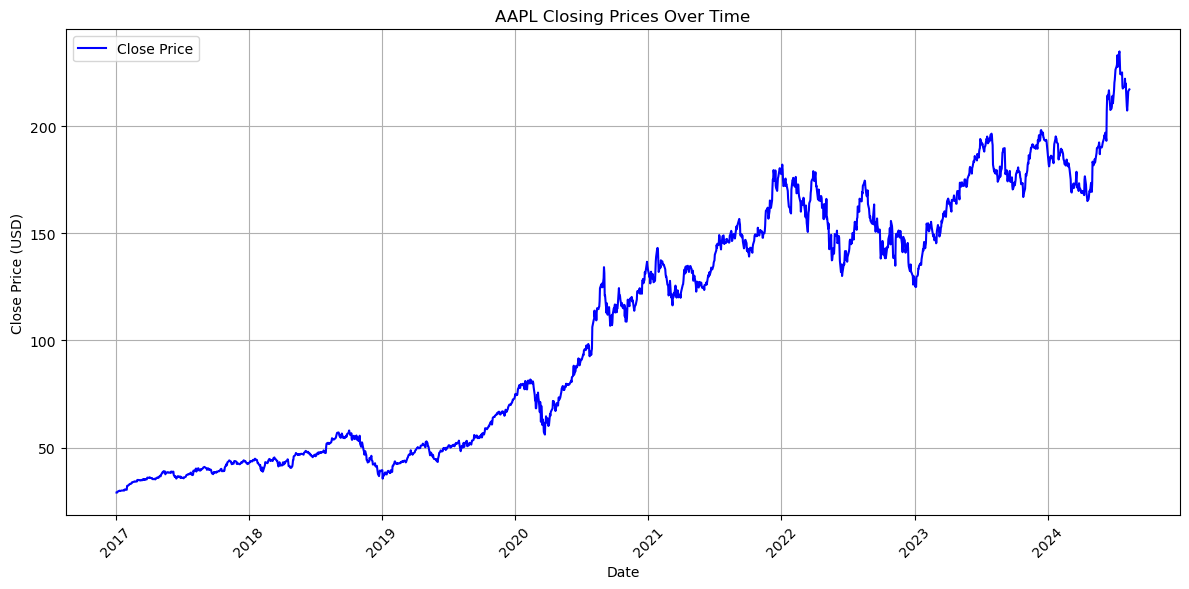

In [64]:
 # Plot the closing prices over time
plt.figure(figsize=(12, 6))
plt.plot(stock_data['date'], stock_data['close'], label='Close Price', color='b')
plt.title(f'{ticker} Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
# stock_data.head()

In [66]:
# Find the minimum and maximum dates from the stock_data DataFrame
min_date = stock_data['date'].min().strftime('%Y-%m-%d')
max_date = stock_data['date'].max().strftime('%Y-%m-%d')
print(f"{ticker} Minimum date: {min_date}")
print(f"{ticker} Maximum date: {max_date}")

AAPL Minimum date: 2017-01-03
AAPL Maximum date: 2024-08-12


## 4. News Data Fetch
Fetch all news for each ticker between 2017 to Current. The Merged_Apple_Articles_With_Sentiment.csv contains all articles until most recent pull. 

In [82]:
# Load the dataset
old_file_path = 'merged_apple_articles_with_sentiment.csv'
current_article_file = pd.read_csv(old_file_path)

# Convert the 'date' column to datetime format
current_article_file['date'] = pd.to_datetime(current_article_file['date'])

# Get the maximum date from the dataset
news_get_min_date = current_article_file['date'].max()

# Get the current date and set it as news_get_max_date
news_get_max_date = datetime.now()

# Format the dates as strings for output
news_get_min_date_str = news_get_min_date.strftime('%Y-%m-%d')
news_get_max_date_str = news_get_max_date.strftime('%Y-%m-%d')

# Flag to check if the file has been updated
file_modified = False

# Check if the dates are the same
if news_get_min_date_str == news_get_max_date_str:
    print("No data needs to be extracted: the minimum and maximum dates are the same.")
    merged_df = current_article_file  # Continue with the old file if no new data is needed
else:
    # Define the API key and ticker for AAPL
    api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'  # Replace with your actual API key
    ticker = 'AAPL'  # Replace with your actual ticker

    # Function to fetch news with pagination
    def fetch_news(ticker, min_date, max_date, max_articles=100000):
        all_articles = []
        url = f"https://api.polygon.io/v2/reference/news?ticker={ticker}&published_utc.gte={min_date}&published_utc.lte={max_date}&apiKey={api_key}&limit=50"

        while len(all_articles) < max_articles:
            response = requests.get(url)
            response.raise_for_status()
            news_data = response.json()

            if not news_data['results']:
                break

            all_articles.extend(news_data['results'])

            if 'next_url' in news_data and news_data['next_url']:
                url = news_data['next_url']
                # Ensure the API key is always included in the next URL
                if "apiKey" not in url:
                    url += f"&apiKey={api_key}"
            else:
                break

        return all_articles[:max_articles]

    # Fetch news for AAPL between the minimum and maximum dates
    all_news = []

    try:
        news_data = fetch_news(ticker, news_get_min_date_str, news_get_max_date_str)
        for article in news_data:
            all_news.append({
                'ticker': ticker,
                'title': article.get('title', 'No Title'),
                'description': article.get('description', 'No Description'),
                'article_url': article.get('article_url', 'No URL'),
                'published_utc': article.get('published_utc', 'No Date'),
                'author': article.get('author', 'No Author'),
                'source': article['publisher']['name'] if article.get('publisher') else 'No Source'
            })
        print(f"Fetched {len(news_data)} articles for {ticker} from {news_get_min_date_str} to {news_get_max_date_str}")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error occurred for {ticker}: {e}")
    except Exception as e:
        print(f"An error occurred for {ticker}: {e}")

    # Create a DataFrame from the collected news
    news_df = pd.DataFrame(all_news)

    # Function to extract article content from a URL with retry mechanism
    def get_article_content_with_retry(url, retries=3, backoff_factor=0.3):
        try:
            response = requests.get(url)
            response.raise_for_status()
            soup = BeautifulSoup(response.content, 'html.parser')
            paragraphs = soup.find_all('p')
            # Filter paragraphs mentioning 'AAPL' or 'Apple'
            filtered_paragraphs = [
                para.get_text() for para in paragraphs if 'AAPL' in para.get_text() or 'Apple' in para.get_text()
            ]
            article_text = ' '.join(filtered_paragraphs)
            return article_text
        except RequestException as e:
            if retries > 0:
                time.sleep(backoff_factor * (3 - retries))
                return get_article_content_with_retry(url, retries - 1, backoff_factor)
            return f"Error: {e}"

    # Apply function with progress bar
    tqdm.pandas()
    news_df['article_content'] = news_df['article_url'].progress_apply(get_article_content_with_retry)

    # Remove rows with 'Error' in 'article_content'
    news_df = news_df[news_df['article_content'].apply(lambda x: not x.startswith("Error:"))]
    print(news_df.shape)

    # Function to extract relevant content mentioning 'AAPL' or 'Apple'
    def extract_relevant_content(text):
        if isinstance(text, str):
            paragraphs = text.split('\n')
            filtered_paragraphs = [para for para in paragraphs if 'AAPL' in para or 'Apple' in para]
            return ' '.join(filtered_paragraphs)
        return ''

    # Apply the function to extract relevant content
    news_df['relevant_content'] = news_df['article_content'].apply(extract_relevant_content)

    # Function to analyze sentiment
    def analyze_sentiment(text):
        blob = TextBlob(text)
        return blob.sentiment.polarity

    # Function to interpret sentiment score
    def interpret_sentiment(score):
        if score > 0.5:
            return "Very Positive"
        elif score > 0:
            return "Positive"
        elif score == 0:
            return "Neutral"
        elif score > -0.5:
            return "Negative"
        else:
            return "Very Negative"

    # Apply sentiment analysis and interpretation
    news_df['sentiment_score'] = news_df['relevant_content'].apply(analyze_sentiment)
    news_df['sentiment'] = news_df['sentiment_score'].apply(interpret_sentiment)

    # Function to clean and reorder the DataFrame
    def clean_and_reorder(df):
        # Convert the 'date' column to datetime format and format it as 'YYYY-MM-DD'
        df['date'] = pd.to_datetime(df['published_utc']).dt.strftime('%Y-%m-%d')
        
        # List of expected columns
        expected_columns = [
            'date', 'published_utc', 'title', 'description', 'article_url',
            'author', 'source', 'article_content', 'relevant_content', 'sentiment_score', 'sentiment'
        ]
        
        # Select and reorder columns to match the expected order
        # Handle any missing columns by setting them to None
        cleaned_df = df.reindex(columns=expected_columns, fill_value=None)
        
        return cleaned_df

    # Clean and reorder the News DataFrame
    news_df_cleaned = clean_and_reorder(news_df)

    # Save the shape of the current_article_file before merge
    current_article_file_shape_before = current_article_file.shape

    # Merge the cleaned DataFrames
    merged_df = pd.concat([news_df_cleaned, current_article_file], ignore_index=True)

    # Ensure the 'date' column is in datetime format
    merged_df['date'] = pd.to_datetime(merged_df['date'], errors='coerce')

    # Sort the merged DataFrame by date in ascending order
    merged_df.sort_values(by='date', ascending=True, inplace=True)

    # Save the shape of the merged DataFrame
    merged_df_shape_after = merged_df.shape

    print("Original current_article_file Shape:", current_article_file_shape_before)
    print("Merged DataFrame Shape:", merged_df_shape_after)

    # Check if the file has been modified
    if merged_df_shape_after != current_article_file_shape_before:
        file_modified = True
        # Save the news DataFrame to a CSV file
        merged_df.to_csv(old_file_path, index=False)
        merged_saved_max_date = merged_df['date'].max()

        print("News File Updated & Saved Successfully. Latest date is:", merged_saved_max_date)
    else:
        print("No new articles were added. Using the old file.")

# Calculate the composite sentiment score by date
# This block is executed regardless of whether the file was modified
composite_sentiment_df = merged_df.groupby('date')['sentiment_score'].mean().reset_index()

# Rename the 'sentiment_score' column to 'composite_sentiment_score'
composite_sentiment_df.rename(columns={'sentiment_score': 'composite_sentiment_score'}, inplace=True)

# Display the temporary DataFrame
print("\nComposite Sentiment Score by Date:")
composite_sentiment_df

Fetched 14 articles for AAPL from 2024-08-11 to 2024-08-12


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:07<00:00,  1.96it/s]


(14, 8)
Original current_article_file Shape: (10356, 10)
Merged DataFrame Shape: (10370, 11)
News File Updated & Saved Successfully. Latest date is: 2024-08-12 00:00:00

Composite Sentiment Score by Date:


,date,composite_sentiment_score
0,2018-11-05,0.131000
1,2018-11-12,0.248000
2,2018-11-18,0.172000
3,2018-11-25,0.172000
4,2018-12-02,0.173000
...,...,...
1216,2024-08-08,0.174383
1217,2024-08-09,0.155140
1218,2024-08-10,0.217699
1219,2024-08-11,0.201212


In [83]:
print(f"News date - Shape: {merged_df.shape}")

# Convert 'published_utc' to datetime format
merged_df['published_utc'] = pd.to_datetime(merged_df['published_utc'])
# Find the minimum and maximum dates in the news DataFrame
news_min_date = merged_df['published_utc'].min().strftime('%Y-%m-%d')
news_max_date = merged_df['published_utc'].max().strftime('%Y-%m-%d')

print(f"News data - Minimum date: {news_min_date}")
print(f"News data - Maximum date: {news_max_date}")
print(f"Composite Sentiment Score - Shape: {composite_sentiment_df.shape}")

News date - Shape: (10370, 11)
News data - Minimum date: 2018-11-05
News data - Maximum date: 2024-08-12
Composite Sentiment Score - Shape: (1221, 2)


## 5. Other Data Points: Financials, Stock Splits, Dividends

In [84]:
# Define the date range based on stock_data
start_date = stock_min_date
end_date = stock_max_date

In [85]:
# Function to fetch stock splits
def fetch_stock_splits(ticker, api_key, start_date, end_date):
    url = (
        f"https://api.polygon.io/v3/reference/splits?"
        f"ticker={ticker}&execution_date.gte={start_date}&execution_date.lte={end_date}&apiKey={api_key}"
    )
    response = requests.get(url)
    response.raise_for_status()
    return response.json()

# Function to fetch dividends
def fetch_dividends(ticker, api_key, start_date, end_date):
    url = (
        f"https://api.polygon.io/v3/reference/dividends?"
        f"ticker={ticker}&ex_dividend_date.gte={start_date}&ex_dividend_date.lte={end_date}&apiKey={api_key}"
    )
    response = requests.get(url)
    response.raise_for_status()
    return response.json()

# Function to fetch financials
def fetch_financials(ticker, api_key, start_date, end_date, max_records=100):
    """Fetch financial data for a given ticker with pagination to get at least 100 records."""
    # Calculate 90 days before the start_date
    min_date = datetime.strptime(start_date, '%Y-%m-%d') - timedelta(days=90)
    min_date = min_date.strftime('%Y-%m-%d')

    all_financials = []
    url = f"https://api.polygon.io/vX/reference/financials?ticker={ticker}&filing_date.gte={min_date}&filing_date.lte={end_date}&limit=50&apiKey={api_key}"

    while len(all_financials) < max_records:
        response = requests.get(url)
        response.raise_for_status()
        data = response.json()

        if 'results' in data:
            all_financials.extend(data['results'])
            if 'next_url' in data and data['next_url']:
                url = data['next_url']
                if "apiKey" not in url:
                    url += f"&apiKey={api_key}"
            else:
                break
        else:
            break

    return all_financials[:max_records]


In [86]:
# Fetch and process data
def fetch_and_process_data(ticker, api_key, start_date, end_date):
    all_splits = []
    all_dividends = []
    all_financials = []

    try:
        splits_data = fetch_stock_splits(ticker, api_key, start_date, end_date)
        dividends_data = fetch_dividends(ticker, api_key, start_date, end_date)
        financials_data = fetch_financials(ticker, api_key, start_date, end_date, max_records=100)

        # Process splits data
        for split in splits_data.get('results', []):
            all_splits.append({
                'ticker': ticker,
                'execution_date': split.get('execution_date', 'N/A'),
                'split_from': split.get('split_from', 'N/A'),
                'split_to': split.get('split_to', 'N/A')
            })

        # Process dividends data
        for dividend in dividends_data.get('results', []):
            all_dividends.append({
                'ticker': ticker,
                'cash_amount': dividend.get('cash_amount', 'N/A'),
                'declaration_date': dividend.get('declaration_date', 'N/A'),
                'ex_dividend_date': dividend.get('ex_dividend_date', 'N/A'),
                'pay_date': dividend.get('pay_date', 'N/A'),
                'record_date': dividend.get('record_date', 'N/A'),
                'frequency': dividend.get('frequency', 'N/A'),
                'dividend_type': dividend.get('dividend_type', 'N/A')
            })

        # Process financials data
        for financial in financials_data:
            all_financials.append({
                'ticker': ticker,
                'filing_date': financial.get('filing_date', 'N/A'),
                'fiscal_year': financial.get('fiscal_year', 'N/A'),
                'fiscal_period': financial.get('fiscal_period', 'N/A'),
                'financials': financial.get('financials', 'N/A'),  # Consider flattening this if needed
                'company_name': financial.get('company_name', 'N/A'),
                'cik': financial.get('cik', 'N/A')
            })

        print(f"Fetched data for {ticker}")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error occurred for {ticker}: {e}")
    except Exception as e:
        print(f"An error occurred for {ticker}: {e}")

    # Convert to DataFrames
    splits_df = pd.DataFrame(all_splits)
    dividends_df = pd.DataFrame(all_dividends)
    financials_df = pd.DataFrame(all_financials)
    
    # Print the shape of each DataFrame
    print(f'Splits DataFrame shape: {splits_df.shape}')
    print(f'Dividends DataFrame shape: {dividends_df.shape}')
    print(f'Financials DataFrame shape: {financials_df.shape}')

    return splits_df, dividends_df, financials_df


In [87]:
# Fetch and process the data
splits_df, dividends_df, financials_df = fetch_and_process_data(ticker, api_key, start_date, end_date)



Fetched data for AAPL
Splits DataFrame shape: (1, 4)
Dividends DataFrame shape: (10, 8)
Financials DataFrame shape: (31, 7)


In [88]:
# Now, you can use these DataFrames
print(f'Splits DataFrame shape: {splits_df.shape}')
splits_df.head(1)

Splits DataFrame shape: (1, 4)


,ticker,execution_date,split_from,split_to
0,AAPL,2020-08-31,1,4


In [89]:
print(f'Dividends DataFrame shape: {dividends_df.shape}')
dividends_df.head(1)

Dividends DataFrame shape: (10, 8)


,ticker,cash_amount,declaration_date,ex_dividend_date,pay_date,record_date,frequency,dividend_type
0,AAPL,0.25,2024-08-01,2024-08-12,2024-08-15,2024-08-12,4,CD


In [90]:
def fetch_financials(ticker, api_key, start_date=None, end_date=None, max_records=100):
    # Define the endpoint URL for financials
    url = f'https://api.polygon.io/vX/reference/financials?ticker={ticker}&apiKey={api_key}'  # Replace vX with the correct version number
    
    # Define parameters for the API request
    params = {
        'limit': max_records
    }

    # Optionally add date filters if provided
    if start_date:
        params['from'] = start_date
    if end_date:
        params['to'] = end_date

    # Make the API request
    response = requests.get(url, params=params)
    
    # Try to decode the JSON response
    try:
        data = response.json()
        if response.status_code == 200 and 'results' in data:
            return data['results']
        else:
            print("Failed to fetch data or no results found.")
            return []
    except ValueError as e:
        print("Error decoding JSON:", e)
        return []

# Define optional date range for filtering
start_date = stock_min_date  # Use the desired start date
end_date = stock_max_date    # Use the desired end date

# Fetch financials data
financials_data = fetch_financials(ticker, api_key, start_date, end_date, max_records=100)

# Process financials data
all_financials = []
for financial in financials_data:
    all_financials.append({
        'ticker': ticker,
        'filing_date': financial.get('filing_date', 'N/A'),
        'fiscal_year': financial.get('fiscal_year', 'N/A'),
        'fiscal_period': financial.get('fiscal_period', 'N/A'),
        'financials': financial.get('financials', 'N/A'),  # Consider flattening this if needed
        'company_name': financial.get('company_name', 'N/A'),
        'cik': financial.get('cik', 'N/A')
    })

# Convert the list to a DataFrame named reportdates_df
reportdates_df = pd.DataFrame(all_financials)

# Ensure filing_date is a datetime object for proper sorting
reportdates_df['filing_date'] = pd.to_datetime(reportdates_df['filing_date'], errors='coerce')

# # Convert fiscal_year to an integer
# reportdates_df['fiscal_year'] = pd.to_numeric(reportdates_df['fiscal_year'], errors='coerce')

# Sort by fiscal year and filing date to ensure Q4 comes after the same year's FY
reportdates_df.sort_values(by=['fiscal_year', 'filing_date'], inplace=True)

# Create a dictionary to map fiscal year to FY filing date
fy_filing_dates = reportdates_df.loc[reportdates_df['fiscal_period'] == 'FY', ['fiscal_year', 'filing_date']].set_index('fiscal_year').to_dict()['filing_date']

# Match Q4 filing date with FY filing date
reportdates_df.loc[reportdates_df['fiscal_period'] == 'Q4', 'filing_date'] = reportdates_df['fiscal_year'].map(fy_filing_dates)

# Remove rows where fiscal_period is FY (since Q4 is now associated with FY)
reportdates_df = reportdates_df[(reportdates_df['fiscal_period'] != 'FY') & (reportdates_df['fiscal_period'] != 'TTM')].reset_index()

# Filter for columns wanted
reportdates_df = reportdates_df[['filing_date', 'fiscal_year', 'fiscal_period']]
# Display the DataFrame
print("Filing Dates and Fiscal Periods:")
reportdates_df.head()

Filing Dates and Fiscal Periods:


,filing_date,fiscal_year,fiscal_period
0,2009-07-22,2009,Q3
1,2009-10-27,2009,Q4
2,2010-01-25,2010,Q1
3,2010-04-21,2010,Q2
4,2010-07-21,2010,Q3


In [92]:
# Map fiscal periods to their respective ending month and day
period_to_date = {
    'Q1': '03-31',
    'Q2': '06-30',
    'Q3': '09-30',
    'Q4': '12-31'
}

# Function to calculate the fiscalDateEnding
def calculate_fiscal_date_ending(row):
    year = row['fiscal_year']
    period_end = period_to_date.get(row['fiscal_period'], '')
    if period_end:
        return f"{year}-{period_end}"
    else:
        return None 

# Apply the function to create the new column
reportdates_df['fiscalDateEnding'] = reportdates_df.apply(calculate_fiscal_date_ending, axis=1)

# Print the updated DataFrame
reportdates_df.tail(10)

,filing_date,fiscal_year,fiscal_period,fiscalDateEnding
50,2022-01-28,2022,Q1,2022-03-31
51,2022-04-29,2022,Q2,2022-06-30
52,2022-07-29,2022,Q3,2022-09-30
53,2022-10-28,2022,Q4,2022-12-31
54,2023-02-03,2023,Q1,2023-03-31
55,2023-05-05,2023,Q2,2023-06-30
56,2023-08-04,2023,Q3,2023-09-30
57,2023-11-03,2023,Q4,2023-12-31
58,2024-02-02,2024,Q1,2024-03-31
59,2024-05-03,2024,Q2,2024-06-30


## 6. INTEREST RATES DATE
#### Grabbing Interest Rates from FRED and create dataframe. Utilized an API to pull data

In [96]:
import requests
import pandas as pd

api_key = '416271d998865865fc8dd1a3bf396bd7'
series_id = 'FEDFUNDS'
start_date = min_date  # Ensure these are formatted as 'YYYY-MM-DD'
end_date = max_date
url = f'https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={api_key}&file_type=json&observation_start={start_date}&observation_end={end_date}'

response = requests.get(url)
data = response.json()

if 'error_code' in data:
    print(f"Error: {data['error_message']}")
else:
    try:
        # Creating a DataFrame from the 'observations' key in the JSON response
        interest_rates = pd.DataFrame(data['observations'])
        
        # Drop 'realtime_start' and 'realtime_end' columns
        interest_rates.drop(columns=['realtime_start', 'realtime_end'], inplace=True)
        
        # Converting 'date' column to datetime type and 'value' column to float type
        interest_rates['date'] = pd.to_datetime(interest_rates['date'])
        interest_rates['value'] = pd.to_numeric(interest_rates['value'], errors='coerce')  # 'coerce' converts invalid parsing to NaN
        
        print("Data fetched and loaded into DataFrame successfully.")
#         # Optionally, set the 'date' as the index of the DataFrame
#         interest_rates.set_index('date', inplace=True)
        
#         print(interest_rates)
    except KeyError:
        print("KeyError: The key 'observations' is not in the response. Check the API request and response.")


Data fetched and loaded into DataFrame successfully.


In [97]:
# Define the renaming dictionary based on your mapping
rename_dict = {
    'value': 'FEDFUNDS',
}

# Rename the columns in the DataFrame
interest_rates.rename(columns=rename_dict, inplace=True)

interest_rates.head()

,date,FEDFUNDS
0,2017-01-01,0.65
1,2017-02-01,0.66
2,2017-03-01,0.79
3,2017-04-01,0.90
4,2017-05-01,0.91


In [100]:
# Ensure 'date' column in stock_data is of datetime type and without time component
stock_data['date'] = pd.to_datetime(stock_data['date']).dt.date

# Create a DataFrame with all dates from stock_data
dates_df = pd.DataFrame(stock_data['date'].unique(), columns=['date'])
dates_df['date'] = pd.to_datetime(dates_df['date']).dt.date

# Ensure 'date' column in interest_rates is of datetime type and without time component
interest_rates['date'] = pd.to_datetime(interest_rates['date']).dt.date

# Merge this DataFrame with the interest_rates DataFrame
interest_rates_expanded = pd.merge(dates_df, interest_rates, on='date', how='outer')

# Forward fill missing values
interest_rates_expanded.sort_values('date', inplace=True)
interest_rates_expanded.ffill(inplace=True)
interest_rates_expanded.reset_index(drop=True, inplace=True)

# Filter out dates not in the original stock_data
interest_rates_final = interest_rates_expanded[interest_rates_expanded['date'].isin(stock_data['date'])]

# Display the final DataFrame
print(interest_rates_final.shape)
interest_rates_final.head()

(1914, 2)


,date,FEDFUNDS
1,2017-01-03,0.65
2,2017-01-04,0.65
3,2017-01-05,0.65
4,2017-01-06,0.65
5,2017-01-09,0.65


## 7. MARKET DATA
#### Grab SPY Market Data from Polygon.io and save only the close data & volumne

In [101]:
# Define the API key
api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'

# Define the start date and the current date
min_date = stock_min_date  # Replace with your desired start date
max_date = stock_max_date  # Use current date as max_date

# Define the endpoint with the dynamic end date for SPY
endpoint = f'https://api.polygon.io/v2/aggs/ticker/SPY/range/1/day/{min_date}/{max_date}'

# Parameters for the API request
params = {
    'adjusted': 'true',
    'sort': 'asc',
    'apiKey': api_key
}

# Make the API request
response = requests.get(endpoint, params=params)
data = response.json()

# Check if the response was successful
if response.status_code == 200:
    # Extract the results
    results = data.get('results', [])
    
    # Convert the results to a DataFrame
    market_df = pd.DataFrame(results)
    
    # Check if the DataFrame is empty
    if market_df.empty:
        print("No data was returned from the API.")
    else:
        # Convert the timestamp from milliseconds to a readable date
        market_df['t'] = pd.to_datetime(market_df['t'], unit='ms')

        # Rename columns for better readability
        market_df.rename(columns={
            't': 'date',
            'o': 'open',
            'h': 'high',
            'l': 'low',
            'c': 'close',
            'v': 'volume',
            'vw': 'volume_weighted_avg_price',
            'n': 'number_of_transactions'
        }, inplace=True)
        
#         # Set the date as the index
#         market_df.set_index('date', inplace=True)

        # Select only the 'close' and 'volume' columns
        market_df = market_df[['date','close', 'volume']]
        market_df['date'] = pd.to_datetime(market_df['date']).dt.date
        print("Data fetched and loaded into DataFrame successfully.")
        
else:
    print("Failed to fetch data. Status Code:", response.status_code)
    print("Response:", data)


Data fetched and loaded into DataFrame successfully.


In [102]:
# Define the renaming dictionary based on your mapping
rename_dict = {
    'close': 'SPY_Close',
    'volume': 'SPY_Volume'
}

# Rename the columns in the DataFrame
market_df.rename(columns=rename_dict, inplace=True)

print(market_df.shape)
market_df.head()

(1914, 3)


,date,SPY_Close,SPY_Volume
0,2017-01-03,225.24,91749603.0
1,2017-01-04,226.58,79018567.0
2,2017-01-05,226.40,78543526.0
3,2017-01-06,227.21,71688083.0
4,2017-01-09,226.46,47175342.0


## 8. Data Cleaning

### STOCK DATA TECHNICAL INDICATORS
#### Create Target Columns for the Stock Data; These will be our predictors for our model

In [104]:
stock_data_transform = stock_data.copy()

In [105]:
# Creating future close prices columns
stock_data_transform['Close_Next_1_Day'] = stock_data_transform['close'].shift(-1)  # Next day close
stock_data_transform['Close_Next_5_Days'] = stock_data_transform['close'].shift(-5)  # 5 days later close
stock_data_transform['Close_Next_30_Days'] = stock_data_transform['close'].shift(-30)  # 30 days later close

# Creating percentage change columns
stock_data_transform['Close_Next1_pctchg'] = stock_data_transform['Close_Next_1_Day'].pct_change() * 100
stock_data_transform['Close_Next5_pctchg'] = stock_data_transform['Close_Next_5_Days'].pct_change(periods=5) * 100
stock_data_transform['Close_Next30_pctchg'] = stock_data_transform['Close_Next_30_Days'].pct_change(periods=30) * 100



#### Create Technical Indicators. These will be used as features for our prediction model

In [106]:
# Calculate SMA_20 and EMA_20
stock_data_transform['SMA_20'] = stock_data_transform['close'].rolling(window=20).mean()
stock_data_transform['EMA_20'] = stock_data_transform['close'].ewm(span=20, adjust=False).mean()


In [107]:
# RSI Calculation Function
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

stock_data_transform['RSI'] = calculate_rsi(stock_data_transform['close'])

In [108]:
# Calculate MACD and MACD Signal
ema_12 = stock_data_transform['close'].ewm(span=12, adjust=False).mean()
ema_26 = stock_data_transform['close'].ewm(span=26, adjust=False).mean()
stock_data_transform['MACD'] = ema_12 - ema_26
stock_data_transform['MACD_Signal'] = stock_data_transform['MACD'].ewm(span=9, adjust=False).mean()


In [109]:
# Calculate Golden Cross without adding SMA_50 and SMA_200 as columns
stock_data_transform['Golden_Cross'] = np.where(
    stock_data_transform['close'].rolling(window=50).mean() > stock_data_transform['close'].rolling(window=200).mean(),
    1, 0)


In [110]:
# Convert the 'date' column to datetime format, ignoring the time
stock_data_transform['date'] = pd.to_datetime(stock_data_transform['date']).dt.date

In [111]:
stock_data_transform.head()

,volume,volume_weighted_avg_price,open,close,high,low,date,number_of_transactions,Close_Next_1_Day,Close_Next_5_Days,Close_Next_30_Days,Close_Next1_pctchg,Close_Next5_pctchg,Close_Next30_pctchg,SMA_20,EMA_20,RSI,MACD,MACD_Signal,Golden_Cross
0,115127460.0,28.9032,28.9500,29.0375,29.0825,28.6900,2017-01-03,158506,29.0050,29.7775,33.8775,NaN,NaN,NaN,NaN,29.037500,NaN,0.000000,0.000000,0
1,84472464.0,29.0330,28.9625,29.0050,29.1275,28.9375,2017-01-04,129946,29.1525,29.9375,33.8363,0.508533,NaN,NaN,NaN,29.034405,NaN,-0.002593,-0.000519,0
2,88774348.0,29.1153,28.9800,29.1525,29.2161,28.9525,2017-01-05,136221,29.4775,29.8125,33.9300,1.114827,NaN,NaN,NaN,29.045652,NaN,0.007172,0.001020,0
3,127007600.0,29.4334,29.1950,29.4775,29.5400,29.1175,2017-01-06,177880,29.7475,29.7600,34.1750,0.915953,NaN,NaN,NaN,29.086780,NaN,0.040667,0.008949,0
4,134247792.0,29.7450,29.4875,29.7475,29.8575,29.4850,2017-01-09,184629,29.7775,30.0000,34.2775,0.100849,NaN,NaN,NaN,29.149706,NaN,0.087984,0.024756,0


In [112]:
# Define the renaming dictionary based on your mapping
rename_dict = {
    'close': 'AAPL_Close',
    'volume': 'AAPL_Volume'
}

# Rename the columns in the DataFrame
stock_data_transform.rename(columns=rename_dict, inplace=True)

# List of columns you want to keep in the DataFrame
desired_columns = [
    'date','AAPL_Close', 'Close_Next_1_Day', 'Close_Next_5_Days', 'Close_Next_30_Days',
    'Close_Next1_pctchg', 'Close_Next5_pctchg', 'Close_Next30_pctchg',
    'SMA_20', 'EMA_20', 'RSI', 'Golden_Cross', 'MACD', 'MACD_Signal', 'AAPL_Volume'
]

# Select only the columns that are in the desired columns list
stock_data_transform_final = stock_data_transform[desired_columns]

# Display the columns to verify
stock_data_transform_final.head()

,date,AAPL_Close,Close_Next_1_Day,Close_Next_5_Days,Close_Next_30_Days,Close_Next1_pctchg,Close_Next5_pctchg,Close_Next30_pctchg,SMA_20,EMA_20,RSI,Golden_Cross,MACD,MACD_Signal,AAPL_Volume
0,2017-01-03,29.0375,29.0050,29.7775,33.8775,NaN,NaN,NaN,NaN,29.037500,NaN,0,0.000000,0.000000,115127460.0
1,2017-01-04,29.0050,29.1525,29.9375,33.8363,0.508533,NaN,NaN,NaN,29.034405,NaN,0,-0.002593,-0.000519,84472464.0
2,2017-01-05,29.1525,29.4775,29.8125,33.9300,1.114827,NaN,NaN,NaN,29.045652,NaN,0,0.007172,0.001020,88774348.0
3,2017-01-06,29.4775,29.7475,29.7600,34.1750,0.915953,NaN,NaN,NaN,29.086780,NaN,0,0.040667,0.008949,127007600.0
4,2017-01-09,29.7475,29.7775,30.0000,34.2775,0.100849,NaN,NaN,NaN,29.149706,NaN,0,0.087984,0.024756,134247792.0


## 9. FINANCIALS DATA
#### Create Financial columns with the financial data list; this will go into our large language model. 
#### Data is extracted from AlphaVantage APIs.

In [113]:

#Alpha Vantage API
# Define your API key and ticker symbol
api_key_alphavantage = 'S6PGD9BYJS8LM870'
#FreeAPIKey = TUY8K02CZUT5DWET

# Convert string dates to datetime objects
stock_min_date_conv = datetime.strptime(stock_min_date, '%Y-%m-%d')
stock_max_date_conv = datetime.strptime(stock_max_date, '%Y-%m-%d')

# Define the minimum date as 90 days before the stock_min_date to get previous financials
min_date = stock_min_date_conv - timedelta(days=90)
max_date = stock_max_date_conv  # Define maximum date

In [114]:
# Define your API key and ticker symbol
api_key = 'S6PGD9BYJS8LM870'
symbol = ticker 

# Function to fetch data and filter by date
def fetch_and_filter_data(api_key, symbol, function, date_column, min_date, max_date):
    url = f'https://www.alphavantage.co/query?function={function}&symbol={symbol}&apikey={api_key}&entitlement=delayed'
    response = requests.get(url)
    data = response.json()

    # Convert data to DataFrame and filter by date
    df = pd.DataFrame(data.get('quarterlyReports', []))
    if not df.empty:
        df[date_column] = pd.to_datetime(df[date_column])
        df = df[(df[date_column] >= min_date) & (df[date_column] <= max_date)]
    return df

# Fetch and filter quarterly financial statements
quarterly_income_statement_filtered = fetch_and_filter_data(api_key, symbol, 'INCOME_STATEMENT', 'fiscalDateEnding', min_date, max_date)
quarterly_balance_sheet_filtered = fetch_and_filter_data(api_key, symbol, 'BALANCE_SHEET', 'fiscalDateEnding', min_date, max_date)
quarterly_cash_flow_filtered = fetch_and_filter_data(api_key, symbol, 'CASH_FLOW', 'fiscalDateEnding', min_date, max_date)

# Merging the DataFrames on 'fiscalDateEnding'
data_frames = [quarterly_income_statement_filtered, quarterly_balance_sheet_filtered, quarterly_cash_flow_filtered]
quarterly_financials = reduce(lambda left, right: pd.merge(left, right, on='fiscalDateEnding', how='outer'), data_frames)

# Display the combined DataFrame
print("Combined Quarterly Financial Statements:")
quarterly_financials.head()



Combined Quarterly Financial Statements:


,fiscalDateEnding,reportedCurrency_x,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,operatingExpenses,investmentIncomeNet,netInterestIncome,interestIncome,interestExpense,nonInterestIncome,otherNonOperatingIncome,depreciation,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,interestAndDebtExpense,netIncomeFromContinuingOperations,comprehensiveIncomeNetOfTax,ebit,ebitda,netIncome_x,reportedCurrency_y,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,cashAndShortTermInvestments,inventory,currentNetReceivables,totalNonCurrentAssets,propertyPlantEquipment,accumulatedDepreciationAmortizationPPE,intangibleAssets,intangibleAssetsExcludingGoodwill,goodwill,investments,longTermInvestments,shortTermInvestments,otherCurrentAssets,otherNonCurrentAssets,totalLiabilities,totalCurrentLiabilities,currentAccountsPayable,deferredRevenue,currentDebt,shortTermDebt,totalNonCurrentLiabilities,capitalLeaseObligations,longTermDebt,currentLongTermDebt,longTermDebtNoncurrent,shortLongTermDebtTotal,otherCurrentLiabilities,otherNonCurrentLiabilities,totalShareholderEquity,treasuryStock,retainedEarnings,commonStock,commonStockSharesOutstanding,reportedCurrency,operatingCashflow,paymentsForOperatingActivities,proceedsFromOperatingActivities,changeInOperatingLiabilities,changeInOperatingAssets,depreciationDepletionAndAmortization,capitalExpenditures,changeInReceivables,changeInInventory,profitLoss,cashflowFromInvestment,cashflowFromFinancing,proceedsFromRepaymentsOfShortTermDebt,paymentsForRepurchaseOfCommonStock,paymentsForRepurchaseOfEquity,paymentsForRepurchaseOfPreferredStock,dividendPayout,dividendPayoutCommonStock,dividendPayoutPreferredStock,proceedsFromIssuanceOfCommonStock,proceedsFromIssuanceOfLongTermDebtAndCapitalSecuritiesNet,proceedsFromIssuanceOfPreferredStock,proceedsFromRepurchaseOfEquity,proceedsFromSaleOfTreasuryStock,changeInCashAndCashEquivalents,changeInExchangeRate,netIncome_y
0,2024-06-30,USD,39678000000,85777000000,52419000000,46099000000,25352000000,6320000000,8006000000,14326000000,None,None,None,None,85777000000,None,None,2850000000,25494000000,4046000000,None,21448000000,21992000000,25352000000,28202000000,21448000000,USD,331612000000,125435000000,25565000000,61801000000,6165000000,43172000000,206177000000,44502000000,72627000000,None,None,None,255441000000,91240000000,36236000000,14297000000,70435000000,264904000000,131624000000,47574000000,20553000000,15108000000,2994000000,133280000000,None,98300000000,12114000000,86196000000,101294000000,60889000000,47084000000,66708000000,None,-4726000000,79850000000,15222259000,USD,28858000000,None,None,4978000000,3294000000,2850000000,2151000000,2094000000,12000000,21448000000,-127000000,-36017000000,1994000000,26522000000,26522000000,None,3895000000,3895000000,None,None,0,None,-26522000000,None,None,None,21448000000
1,2024-03-31,USD,42271000000,90753000000,54950000000,48482000000,27900000000,6468000000,7903000000,14371000000,None,None,None,None,90753000000,None,None,2836000000,28058000000,4422000000,None,23636000000,24054000000,27900000000,30736000000,23636000000,USD,337411000000,128416000000,32695000000,67150000000,6232000000,41150000000,208995000000,43546000000,71697000000,None,None,None,261876000000,95187000000,34455000000,13884000000,70262000000,263217000000,123822000000,45753000000,20612000000,12759000000,1997000000,139395000000,None,102600000000,10762000000,91831000000,104597000000,57298000000,47564000000,74194000000,None,4339000000,78815000000,15337686000,USD,22690000000,None,None,-11740000000,-5976000000,2836000000,1996000000,-8767000000,-190000000,23636000000,-310000000,-30433000000,4000000,23205000000,23205000000,None,3710000000,3710000000,None,None,0,None,-23205000000,None,None,None,23636000000
2,2023-12-31,USD,54855000000,119575000000,71506000000,64720000000,40373000000,6786000000,7696000000,14482000000,None,None,None,1002000000,119575000000,None,None,28480

#### Merge ReportDates df with Quarterlyfinancials to get Report dates

In [115]:
# Ensure that fiscalDateEnding is the correct data type
quarterly_financials['fiscalDateEnding'] = pd.to_datetime(quarterly_financials['fiscalDateEnding'])
reportdates_df['fiscalDateEnding'] = pd.to_datetime(reportdates_df['fiscalDateEnding'])

# Merge filing_date from reportdates_df to quarterly_financials
# Matching 'fiscalDateEnding' in both dataframes
merged_financials = pd.merge(quarterly_financials, reportdates_df[['fiscalDateEnding', 'filing_date']],
                             on='fiscalDateEnding', how='left')

# Display the result to verify the merge
print("Merged Quarterly Financial Statements with Filing Dates:")
merged_financials.head()

Merged Quarterly Financial Statements with Filing Dates:


,fiscalDateEnding,reportedCurrency_x,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,operatingExpenses,investmentIncomeNet,netInterestIncome,interestIncome,interestExpense,nonInterestIncome,otherNonOperatingIncome,depreciation,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,interestAndDebtExpense,netIncomeFromContinuingOperations,comprehensiveIncomeNetOfTax,ebit,ebitda,netIncome_x,reportedCurrency_y,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,cashAndShortTermInvestments,inventory,currentNetReceivables,totalNonCurrentAssets,propertyPlantEquipment,accumulatedDepreciationAmortizationPPE,intangibleAssets,intangibleAssetsExcludingGoodwill,goodwill,investments,longTermInvestments,shortTermInvestments,otherCurrentAssets,otherNonCurrentAssets,totalLiabilities,totalCurrentLiabilities,currentAccountsPayable,deferredRevenue,currentDebt,shortTermDebt,totalNonCurrentLiabilities,capitalLeaseObligations,longTermDebt,currentLongTermDebt,longTermDebtNoncurrent,shortLongTermDebtTotal,otherCurrentLiabilities,otherNonCurrentLiabilities,totalShareholderEquity,treasuryStock,retainedEarnings,commonStock,commonStockSharesOutstanding,reportedCurrency,operatingCashflow,paymentsForOperatingActivities,proceedsFromOperatingActivities,changeInOperatingLiabilities,changeInOperatingAssets,depreciationDepletionAndAmortization,capitalExpenditures,changeInReceivables,changeInInventory,profitLoss,cashflowFromInvestment,cashflowFromFinancing,proceedsFromRepaymentsOfShortTermDebt,paymentsForRepurchaseOfCommonStock,paymentsForRepurchaseOfEquity,paymentsForRepurchaseOfPreferredStock,dividendPayout,dividendPayoutCommonStock,dividendPayoutPreferredStock,proceedsFromIssuanceOfCommonStock,proceedsFromIssuanceOfLongTermDebtAndCapitalSecuritiesNet,proceedsFromIssuanceOfPreferredStock,proceedsFromRepurchaseOfEquity,proceedsFromSaleOfTreasuryStock,changeInCashAndCashEquivalents,changeInExchangeRate,netIncome_y,filing_date
0,2024-06-30,USD,39678000000,85777000000,52419000000,46099000000,25352000000,6320000000,8006000000,14326000000,None,None,None,None,85777000000,None,None,2850000000,25494000000,4046000000,None,21448000000,21992000000,25352000000,28202000000,21448000000,USD,331612000000,125435000000,25565000000,61801000000,6165000000,43172000000,206177000000,44502000000,72627000000,None,None,None,255441000000,91240000000,36236000000,14297000000,70435000000,264904000000,131624000000,47574000000,20553000000,15108000000,2994000000,133280000000,None,98300000000,12114000000,86196000000,101294000000,60889000000,47084000000,66708000000,None,-4726000000,79850000000,15222259000,USD,28858000000,None,None,4978000000,3294000000,2850000000,2151000000,2094000000,12000000,21448000000,-127000000,-36017000000,1994000000,26522000000,26522000000,None,3895000000,3895000000,None,None,0,None,-26522000000,None,None,None,21448000000,2024-05-03
1,2024-03-31,USD,42271000000,90753000000,54950000000,48482000000,27900000000,6468000000,7903000000,14371000000,None,None,None,None,90753000000,None,None,2836000000,28058000000,4422000000,None,23636000000,24054000000,27900000000,30736000000,23636000000,USD,337411000000,128416000000,32695000000,67150000000,6232000000,41150000000,208995000000,43546000000,71697000000,None,None,None,261876000000,95187000000,34455000000,13884000000,70262000000,263217000000,123822000000,45753000000,20612000000,12759000000,1997000000,139395000000,None,102600000000,10762000000,91831000000,104597000000,57298000000,47564000000,74194000000,None,4339000000,78815000000,15337686000,USD,22690000000,None,None,-11740000000,-5976000000,2836000000,1996000000,-8767000000,-190000000,23636000000,-310000000,-30433000000,4000000,23205000000,23205000000,None,3710000000,3710000000,None,None,0,None,-23205000000,None,None,None,23636000000,2024-02-02
2,2023-12-31,USD,54855000000,119575000000,71506000000,64720000000,40373000000,6786000000,7696000000,14482000000,None,None,None,10020

In [432]:
# merged_financials.shape

In [431]:
# merged_financials.columns

In [116]:
# Create the new DataFrame
master_merged_financials = merged_financials.copy()

# Create or initialize missing columns to avoid KeyError
if 'totalDebtService' not in master_merged_financials.columns:
    master_merged_financials['totalDebtService'] = np.nan  # Initialize with NaN

if 'fixedCharges' not in master_merged_financials.columns:
    master_merged_financials['fixedCharges'] = 0  # Initialize with 0

# Ensure all columns involved in calculations are numeric
cols_to_convert = [
    'operatingCashflow', 'totalDebtService', 'ebit', 'fixedCharges', 'interestExpense',
    'totalCurrentAssets', 'totalCurrentLiabilities', 'inventory', 'totalLiabilities', 
    'totalShareholderEquity', 'grossProfit', 'totalRevenue', 'operatingIncome', 
    'netIncomeFromContinuingOperations', 'totalAssets', 'commonStockSharesOutstanding',
    'totalCurrentAssets', 'totalCurrentLiabilities', 'totalLiabilities', 
    'cashAndCashEquivalentsAtCarryingValue', 'operatingCashflow', 'capitalExpenditures',
    'operatingIncome', 'interestExpense', 'ebitda',
    'shortTermDebt', 'longTermDebt', 'propertyPlantEquipment', 
    'accumulatedDepreciationAmortizationPPE', 'totalShareholderEquity'
    
]

for col in cols_to_convert:
    master_merged_financials[col] = pd.to_numeric(master_merged_financials[col], errors='coerce')

# Calculate financial ratios using master_merged_financials
master_merged_financials['CurrentRatio'] = master_merged_financials['totalCurrentAssets'] / master_merged_financials['totalCurrentLiabilities']
master_merged_financials['QuickRatio'] = (master_merged_financials['totalCurrentAssets'] - master_merged_financials['inventory']) / master_merged_financials['totalCurrentLiabilities']
master_merged_financials['DebtToEquityRatio'] = master_merged_financials['totalLiabilities'] / master_merged_financials['totalShareholderEquity']
master_merged_financials['GrossMargin'] = master_merged_financials['grossProfit'] / master_merged_financials['totalRevenue']
master_merged_financials['OperatingMargin'] = master_merged_financials['operatingIncome'] / master_merged_financials['totalRevenue']
master_merged_financials['NetProfitMargin'] = master_merged_financials['netIncomeFromContinuingOperations'] / master_merged_financials['totalRevenue']
master_merged_financials['ReturnOnAssets'] = master_merged_financials['netIncomeFromContinuingOperations'] / master_merged_financials['totalAssets']
master_merged_financials['ReturnOnEquity'] = master_merged_financials['netIncomeFromContinuingOperations'] / master_merged_financials['totalShareholderEquity']

# Calculate Debt Service Coverage Ratio and Fixed Charge Coverage Ratio
master_merged_financials['DebtServiceCoverageRatio'] = np.where(
    master_merged_financials['totalDebtService'] > 0,
    master_merged_financials['operatingCashflow'] / master_merged_financials['totalDebtService'],
    np.nan  # Set NaN if totalDebtService is zero
)
master_merged_financials['FixedChargeCoverageRatio'] = np.where(
    (master_merged_financials['fixedCharges'] + master_merged_financials['interestExpense']) > 0,
    (master_merged_financials['ebit'] + master_merged_financials['fixedCharges']) / 
    (master_merged_financials['fixedCharges'] + master_merged_financials['interestExpense']),
    np.nan  # Set NaN if fixedCharges plus interestExpense is zero
)

# Calculate EPS
master_merged_financials['BasicEPS'] = master_merged_financials['netIncomeFromContinuingOperations'] / master_merged_financials['commonStockSharesOutstanding']
master_merged_financials['DilutedEPS'] = master_merged_financials['netIncomeFromContinuingOperations'] / master_merged_financials['commonStockSharesOutstanding']  # Adjust if you have diluted shares
master_merged_financials['EPS'] = master_merged_financials['netIncomeFromContinuingOperations'] / master_merged_financials['commonStockSharesOutstanding']



# Calculating Change in Working Capital
master_merged_financials['ChangeInWorkingCapital'] = master_merged_financials['totalCurrentAssets'] - master_merged_financials['totalCurrentLiabilities']

# Calculating Net Debt
master_merged_financials['NetDebt'] = master_merged_financials['totalLiabilities'] - master_merged_financials['cashAndCashEquivalentsAtCarryingValue']

# Calculating Free Cash Flow
master_merged_financials['FreeCashFlow'] = master_merged_financials['operatingCashflow'] - master_merged_financials['capitalExpenditures']

# Assuming EBIT as operatingIncome (since EBIT calculation needs more specific details which may or may not be present)
master_merged_financials['EBIT'] = master_merged_financials['operatingIncome']

# Ensuring EBITDA is calculated if missing
master_merged_financials['EBITDA'] = master_merged_financials['ebitda']  # Assuming it's correct or needs adjustment based on actual definitions

# Rename columns
master_merged_financials.rename(columns={'netIncome_x': 'NetIncome'}, inplace=True)
# Drop the 'netIncome_y' column from the DataFrame
master_merged_financials = master_merged_financials.drop(columns=['netIncome_y'])

# Rename other columns
master_merged_financials.rename(columns={'totalCurrentAssets': 'CurrentAssets',
                                         'otherCurrentAssets': 'OtherCurrentAssets',
                                         'grossProfit': 'GrossProfit',
                                         'totalRevenue': 'TotalRevenue',
                                         'costOfRevenue':'CostOfRevenue',
                                         'operatingIncome':'OperatingIncome',
                                         'sellingGeneralAndAdministrative':'SellingGeneralAndAdministration',
                                         'researchAndDevelopment':'ResearchAndDevelopment',
                                        'operatingExpenses': 'OperatingExpense',
                                        'investmentIncomeNet': 'InvestmentIncomeNet',
                                        'netInterestIncome': 'NetInterestIncome',
                                        'interestIncome': 'InterestIncome',
                                        'interestExpense': 'InterestExpense',
                                        'nonInterestIncome': 'NonInterestIncome',
                                        'otherNonOperatingIncome': 'OtherNonOperatingIncome',
                                        'depreciation': 'Depreciation',
                                        'depreciationAndAmortization': 'DepreciationAndAmortization',
                                        'incomeBeforeTax': 'IncomeBeforeTax',
                                        'incomeTaxExpense': 'IncomeTaxExpense',
                                        'interestAndDebtExpense': 'InterestAndDebtExpense',
                                        'netIncomeFromContinuingOperations': 'NetIncomeFromContinuingOperations',
                                        'comprehensiveIncomeNetOfTax': 'ComprehensiveIncomeNetOfTax',
                                        'ebit': 'EBIT',
                                        'ebitda': 'EBITDA',
                                        'totalAssets': 'TotalAssets',
                                        'cashAndCashEquivalentsAtCarryingValue': 'CashAndCashEquivalentsAtCarryingValue',
                                        'cashAndShortTermInvestments': 'CashAndShortTermInvestments',
                                        'inventory': 'Inventory',
                                        'currentNetReceivables': 'CurrentNetReceivables',
                                        'totalNonCurrentAssets': 'TotalNonCurrentAssets',
                                        'propertyPlantEquipment': 'PropertyPlantEquipment',
                                        'accumulatedDepreciationAmortizationPPE': 'AccumulatedDepreciationAmortizationPPE',
                                        'intangibleAssets': 'IntangibleAssets',
                                        'intangibleAssetsExcludingGoodwill': 'IntangibleAssetsExcludingGoodwill',
                                        'goodwill': 'Goodwill',
                                        'investments': 'Investments',
                                        'longTermInvestments': 'LongTermInvestments',
                                        'shortTermInvestments': 'ShortTermInvestments',
                                        'otherCurrentAssets': 'OtherCurrentAssets',
                                        'otherNonCurrentAssets': 'OtherNonCurrentAssets',
                                        'totalLiabilities': 'TotalLiabilities',
                                        'totalCurrentLiabilities': 'TotalCurrentLiabilities',
                                        'currentAccountsPayable': 'CurrentAccountsPayable',
                                        'deferredRevenue': 'DeferredRevenue',
                                        'currentDebt': 'CurrentDebt',
                                        'shortTermDebt': 'ShortTermDebt',
                                        'totalNonCurrentLiabilities': 'TotalNonCurrentLiabilities',
                                        'capitalLeaseObligations': 'CapitalLeaseObligations',
                                        'longTermDebt': 'LongTermDebt',
                                        'currentLongTermDebt': 'CurrentLongTermDebt',
                                        'longTermDebtNoncurrent': 'LongTermDebtNoncurrent',
                                        'shortLongTermDebtTotal': 'ShortLongTermDebtTotal',
                                        'otherCurrentLiabilities': 'OtherCurrentLiabilities',
                                        'otherNonCurrentLiabilities': 'OtherNonCurrentLiabilities',
                                        'totalShareholderEquity': 'TotalShareholderEquity',
                                        'treasuryStock': 'TreasuryStock',
                                        'retainedEarnings': 'RetainedEarnings',
                                        'commonStock': 'CommonStock',
                                        'commonStockSharesOutstanding': 'CommonStockSharesOutstanding',
                                        'reportedCurrency': 'ReportedCurrency',
                                        'operatingCashflow': 'OperatingCashFlow',
                                        'paymentsForOperatingActivities': 'PaymentsForOperatingActivities',
                                        'proceedsFromOperatingActivities': 'ProceedsFromOperatingActivities',
                                        'changeInOperatingLiabilities': 'ChangeInOperatingLiabilities',
                                        'changeInOperatingAssets': 'ChangeInOperatingAssets',
                                        'depreciationDepletionAndAmortization': 'DepreciationDepletionAndAmortization',
                                        'capitalExpenditures': 'CapitalExpenditures',
                                        'changeInReceivables': 'ChangeInReceivables',
                                        'changeInInventory': 'ChangeInInventory',
                                        'profitLoss': 'ProfitLoss',
                                        'cashflowFromInvestment': 'CashflowFromInvestment',
                                        'cashflowFromFinancing': 'CashflowFromFinancing',
                                        'proceedsFromRepaymentsOfShortTermDebt': 'ProceedsFromRepaymentsOfShortTermDebt',
                                        'paymentsForRepurchaseOfCommonStock': 'PaymentsForRepurchaseOfCommonStock',
                                        'paymentsForRepurchaseOfEquity': 'PaymentsForRepurchaseOfEquity',
                                        'paymentsForRepurchaseOfPreferredStock': 'PaymentsForRepurchaseOfPreferredStock',
                                        'dividendPayout': 'DividendPayout',
                                        'dividendPayoutCommonStock': 'DividendPayoutCommonStock',
                                        'dividendPayoutPreferredStock': 'DividendPayoutPreferredStock',
                                        'proceedsFromIssuanceOfCommonStock': 'ProceedsFromIssuanceOfCommonStock',
                                        'proceedsFromIssuanceOfLongTermDebtAndCapitalSecuritiesNet': 'ProceedsFromIssuanceOfLongTermDebtAndCapitalSecuritiesNet',
                                        'proceedsFromIssuanceOfPreferredStock': 'ProceedsFromIssuanceOfPreferredStock',
                                        'proceedsFromRepurchaseOfEquity': 'ProceedsFromRepurchaseOfEquity',
                                        'proceedsFromSaleOfTreasuryStock': 'ProceedsFromSaleOfTreasuryStock',
                                        'changeInCashAndCashEquivalents': 'ChangeInCashAndCashEquivalents',
                                        'changeInExchangeRate': 'ChangeInExchangeRate',
                                        'filing_date': 'FilingDate',
                                        'totalDebtService': 'TotalDebtService',
                                        'fixedCharges': 'FixedCharges'

                                         
                                         
   
                                    }, inplace=True)

In [117]:
# Ensure that the columns involved in arithmetic operations are numeric
master_merged_financials['OperatingExpense'] = pd.to_numeric(master_merged_financials['OperatingExpense'], errors='coerce')
master_merged_financials['InterestExpense'] = pd.to_numeric(master_merged_financials['InterestExpense'], errors='coerce')

# Summing up operating expenses and interest expense
master_merged_financials['TotalExpenses'] = master_merged_financials['OperatingExpense'] + master_merged_financials['InterestExpense']

# Example of initializing with correct types or handling missing columns
if 'NetInvestmentPurchaseAndSale' not in master_merged_financials:
    master_merged_financials['NetInvestmentPurchaseAndSale'] = pd.to_numeric(master_merged_financials['ProceedsFromSaleOfTreasuryStock'], errors='coerce') - \
                                                               pd.to_numeric(master_merged_financials['ProceedsFromIssuanceOfPreferredStock'], errors='coerce')

master_merged_financials['ProceedsFromSaleOfTreasuryStock'] = pd.to_numeric(master_merged_financials['ProceedsFromSaleOfTreasuryStock'], errors='coerce')
master_merged_financials['ProceedsFromIssuanceOfPreferredStock'] = pd.to_numeric(master_merged_financials['ProceedsFromIssuanceOfPreferredStock'], errors='coerce')

# Replace NaN with 0 if it makes sense in your context
master_merged_financials['ProceedsFromSaleOfTreasuryStock'].fillna(0, inplace=True)
master_merged_financials['ProceedsFromIssuanceOfPreferredStock'].fillna(0, inplace=True)

# Now perform the subtraction
master_merged_financials['NetInvestmentPurchaseAndSale'] = master_merged_financials['ProceedsFromSaleOfTreasuryStock'] - master_merged_financials['ProceedsFromIssuanceOfPreferredStock']


# Convert 'currentAccountsPayable' to numeric, handling non-numeric values by coercing them to NaN
master_merged_financials['CurrentAccountsPayable'] = pd.to_numeric(master_merged_financials['CurrentAccountsPayable'], errors='coerce')
# Now apply the diff() method
master_merged_financials['ChangeInPayable'] = master_merged_financials['CurrentAccountsPayable'].diff()


# Convert 'currentNetReceivables' to numeric, handling non-numeric values by coercing them to NaN
master_merged_financials['CurrentNetReceivables'] = pd.to_numeric(master_merged_financials['CurrentNetReceivables'], errors='coerce')
# Now apply the diff() method to calculate changes in account receivables
master_merged_financials['ChangesInAccountReceivables'] = master_merged_financials['CurrentNetReceivables'].diff()

# Convert relevant columns to numeric, handling non-numeric values by coercing them to NaN
columns_to_convert = ['PropertyPlantEquipment', 'AccumulatedDepreciationAmortizationPPE', 'OtherPPE']

for col in columns_to_convert:
    if col in master_merged_financials.columns:
        master_merged_financials[col] = pd.to_numeric(master_merged_financials[col], errors='coerce')

# Now compute 'GrossPPE' with the corrected data types
master_merged_financials['GrossPPE'] = master_merged_financials['PropertyPlantEquipment'] + master_merged_financials.get('otherPPE', 0) - master_merged_financials['AccumulatedDepreciationAmortizationPPE']




# Create or update columns based on existing data
# master_merged_financials['OperatingExpense'] = master_merged_financials['operatingExpenses']  
master_merged_financials['PretaxIncome'] = master_merged_financials['IncomeBeforeTax']  
master_merged_financials['InvestingCashFlow'] = master_merged_financials['CashflowFromInvestment']  
master_merged_financials['CapitalExpenditure'] = master_merged_financials['CapitalExpenditures']  
master_merged_financials['FinancingCashFlow'] = master_merged_financials['CashflowFromFinancing']  
master_merged_financials['ChangeInAccountPayable'] = master_merged_financials['ChangeInOperatingLiabilities']  # Approximation
master_merged_financials['AccountsPayable'] = master_merged_financials['CurrentAccountsPayable']  
master_merged_financials['CashEquivalents'] = master_merged_financials['CashAndCashEquivalentsAtCarryingValue']  
master_merged_financials['AccountsReceivable'] = master_merged_financials['CurrentNetReceivables']  
master_merged_financials['AccumulatedDepreciation'] = master_merged_financials['AccumulatedDepreciationAmortizationPPE']  
master_merged_financials['CashAndCashEquivalents'] = master_merged_financials['CashAndCashEquivalentsAtCarryingValue']  
master_merged_financials['ChangeInInventory'] = master_merged_financials['ChangeInInventory']  
master_merged_financials['CurrentDebt'] = master_merged_financials['CurrentDebt']  
master_merged_financials['DepreciationAndAmortization'] = master_merged_financials['DepreciationAndAmortization']  
master_merged_financials['LongTermDebt'] = master_merged_financials['LongTermDebt']  
master_merged_financials['NetIncomeContinuousOperations'] = master_merged_financials['NetIncomeFromContinuingOperations']  
master_merged_financials['OtherInvestments'] = np.nan  # Placeholder if no direct column matches
master_merged_financials['Payables'] = master_merged_financials['CurrentAccountsPayable']  
master_merged_financials['PurchaseOfInvestment'] = master_merged_financials['ProceedsFromSaleOfTreasuryStock']  # Placeholder, adjust as needed
master_merged_financials['SaleOfInvestment'] = master_merged_financials['ProceedsFromSaleOfTreasuryStock']  
master_merged_financials['CapitalStock'] = master_merged_financials['CommonStock']  
master_merged_financials['NetInvestmentPurchaseAndSale'] = master_merged_financials['ProceedsFromSaleOfTreasuryStock'] - master_merged_financials['ProceedsFromIssuanceOfPreferredStock']  # Calculated as difference
master_merged_financials['NetIssuancePaymentsOfDebt'] = master_merged_financials['ProceedsFromIssuanceOfLongTermDebtAndCapitalSecuritiesNet']  
master_merged_financials['ResearchAndDevelopment'] = master_merged_financials['ResearchAndDevelopment']  
master_merged_financials['SellingGeneralAndAdministration'] = master_merged_financials['SellingGeneralAndAdministration']  
master_merged_financials['TotalNonCurrentAssets'] = master_merged_financials['TotalNonCurrentAssets']  
master_merged_financials['TotalNonCurrentLiabilitiesNetMinorityInterest'] = master_merged_financials['TotalNonCurrentLiabilities']  # Adjust if minority interest is available
master_merged_financials['TotalExpenses'] = master_merged_financials['OperatingExpense'] + master_merged_financials['InterestExpense']  # Sum of operating expenses and interest expenses

master_merged_financials['AvailableForSaleSecurities'] = np.nan
master_merged_financials['CashFinancial'] = master_merged_financials['CashAndCashEquivalentsAtCarryingValue']
master_merged_financials['ChangeInPayable'] = master_merged_financials['CurrentAccountsPayable'].diff()  # Requires time-series data
master_merged_financials['ChangesInAccountReceivables'] = master_merged_financials['CurrentNetReceivables'].diff()
master_merged_financials['OtherCurrentBorrowings'] = np.nan
master_merged_financials['GrossPPE'] = master_merged_financials['PropertyPlantEquipment'] + master_merged_financials.get('OtherPPE', 0) - master_merged_financials['AccumulatedDepreciationAmortizationPPE']
master_merged_financials['InvestmentinFinancialAssets'] = master_merged_financials['Investments'] + master_merged_financials['LongTermInvestments'] + master_merged_financials['ShortTermInvestments']


master_merged_financials['NetLongTermDebtIssuance'] = np.nan  # Requires previous period data
master_merged_financials['NetShortTermDebtIssuance'] = np.nan
master_merged_financials['PurchaseOfBusiness'] = np.nan
master_merged_financials['OtherEquityAdjustments'] = np.nan
master_merged_financials['OtherReceivables'] = np.nan
master_merged_financials['OtherShortTermInvestments'] = np.nan
master_merged_financials['CurrentDeferredRevenue'] = np.nan
master_merged_financials['DepreciationAmortizationDepletion'] = master_merged_financials['DepreciationAndAmortization']
master_merged_financials['NetOtherFinancingCharges'] = np.nan
master_merged_financials['NetOtherInvestingChanges'] = np.nan
master_merged_financials['PurchaseOfBusiness'] = np.nan  
master_merged_financials['OtherEquityAdjustments'] = np.nan  
master_merged_financials['OtherReceivables'] = np.nan  
master_merged_financials['OtherShortTermInvestments'] = np.nan  
master_merged_financials['CurrentDeferredRevenue'] = np.nan  
master_merged_financials['DepreciationAmortizationDepletion'] = master_merged_financials['DepreciationAndAmortization']  
master_merged_financials['NetOtherFinancingCharges'] = np.nan  
master_merged_financials['NetOtherInvestingChanges'] = np.nan  


master_merged_financials['WorkingCapital'] = master_merged_financials['CurrentAssets'] - master_merged_financials['TotalCurrentLiabilities']
master_merged_financials['TotalDebt'] = master_merged_financials.get('ShortTermDebt', 0) + master_merged_financials.get('LongTermDebt', 0)
master_merged_financials['NetPPE'] = master_merged_financials.get('propertyPlantEquipment', 0) - master_merged_financials.get('AccumulatedDepreciationAmortizationPPE', 0)
master_merged_financials['TotalCapitalization'] = master_merged_financials['TotalDebt'] + master_merged_financials['TotalShareholderEquity']



C:\Users\matt_\AppData\Local\Temp\ipykernel_43944\2391335785.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_merged_financials['ProceedsFromSaleOfTreasuryStock'].fillna(0, inplace=True)
C:\Users\matt_\AppData\Local\Temp\ipykernel_43944\2391335785.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  master_merged_financials['ProceedsFromIssuanceOfPreferredStock'].fillna(0, inplace=True)


In [118]:
# Convert existing columns to numeric for calculations
columns_to_convert = [
    'CashAndCashEquivalents', 'ShortTermInvestments', 'CurrentDebt', 'CapitalLeaseObligations',
    'LongTermDebt', 'PropertyPlantEquipment', 'AccumulatedDepreciationAmortizationPPE',
    'AccountsPayable'
]
for col in columns_to_convert:
    if col in master_merged_financials.columns:
        master_merged_financials[col] = pd.to_numeric(master_merged_financials[col], errors='coerce')

# Calculable columns
if 'CashAndCashEquivalents' in master_merged_financials and 'ShortTermInvestments' in master_merged_financials:
    master_merged_financials['CashCashEquivalentsAndShortTermInvestments'] = (
        master_merged_financials['CashAndCashEquivalents'] + master_merged_financials['ShortTermInvestments']
    )

if 'CurrentDebt' in master_merged_financials and 'CapitalLeaseObligations' in master_merged_financials:
    master_merged_financials['CurrentDebtAndCapitalLeaseObligation'] = (
        master_merged_financials['CurrentDebt'] + master_merged_financials['CapitalLeaseObligations']
    )

if 'LongTermDebt' in master_merged_financials and 'CapitalLeaseObligations' in master_merged_financials:
    master_merged_financials['LongTermDebtAndCapitalLeaseObligation'] = (
        master_merged_financials['LongTermDebt'] + master_merged_financials['CapitalLeaseObligations']
    )

if 'PropertyPlantEquipment' in master_merged_financials and 'AccumulatedDepreciationAmortizationPPE' in master_merged_financials:
    master_merged_financials['NetPPE'] = (
        master_merged_financials['PropertyPlantEquipment'] - master_merged_financials['AccumulatedDepreciationAmortizationPPE']
    )

if 'TotalCurrentLiabilities' in master_merged_financials:
    master_merged_financials['CurrentLiabilities'] = master_merged_financials['TotalCurrentLiabilities']

if 'TotalRevenue' in master_merged_financials:
    master_merged_financials['OperatingRevenue'] = master_merged_financials['TotalRevenue']

# Add columns with NaN where calculations are not possible
columns_with_nan = [
    'ChangeInOtherCurrentLiabilities', 'ChangeInOtherWorkingCapital', 'PurchaseOfPPE', 'CurrentDeferredLiabilities',
    'GainsLossesNotAffectingRetainedEarnings', 'InvestmentsAndAdvances', 'NetCommonStockIssuance',
    'NetIncomeIncludingNoncontrollingInterests', 'NetPPEPurchaseAndSale', 'PayablesAndAccruedExpenses',
    'Receivables', 'StockBasedCompensation', 'BeginningCashPosition', 'CashFlowFromContinuingFinancingActivities',
    'CashFlowFromContinuingInvestingActivities', 'CashFlowFromContinuingOperatingActivities', 'ChangesInCash',
    'BasicAverageShares', 'CommonStockEquity', 'DilutedAverageShares', 'DilutedNIAvailtoComStockholders',
    'EndCashPosition', 'NetIncomeCommonStockholders', 'NetIncomeFromContinuingAndDiscontinuedOperation',
    'NetIncomeFromContinuingOperationNetMinorityInterest', 'NormalizedEBITDA', 'NormalizedIncome',
    'OrdinarySharesNumber', 'OtherIncomeExpense', 'TotalLiabilitiesNetMinorityInterest', 'TotalOperatingIncomeAsReported'
]

for col in columns_with_nan:
    if col not in master_merged_financials.columns:
        master_merged_financials[col] = np.nan


#### Error Handling 

In [650]:
# master_merged_financials.shape

In [599]:
# master_merged_financials = master_merged_financials.drop(columns=['costofGoodsAndServicesSold'])

In [649]:
# master_merged_financials.head()

In [648]:
# for col in master_merged_financials.columns:
#     print(col)
    
# print(len(master_merged_financials.columns))

In [647]:
# sheet_list = ['CurrentRatio',	'QuickRatio',	'DebtToEquityRatio',	'GrossMargin',	'OperatingMargin',	'NetProfitMargin',	'ReturnOnAssets',	'ReturnOnEquity',	'EPS',	'BasicEPS',	'DilutedEPS',	'DebtServiceCoverageRatio',	'FixedChargeCoverageRatio',	'TotalRevenue',	'CostOfRevenue',	'GrossProfit',	'OperatingExpense',	'OperatingIncome',	'PretaxIncome',	'TotalAssets',	'OperatingCashFlow',	'InvestingCashFlow',	'CapitalExpenditure',	'FinancingCashFlow',	'ChangeInAccountPayable',	'AccountsPayable',	'AvailableForSaleSecurities',	'CashEquivalents',	'CashFinancial',	'ChangeInPayable',	'ChangesInAccountReceivables',	'OtherCurrentBorrowings',	'AccountsReceivable',	'AccumulatedDepreciation',	'CashAndCashEquivalents',	'ChangeInInventory',	'ChangeInOtherCurrentLiabilities',	'ChangeInOtherWorkingCapital',	'CurrentDebt',	'CurrentDeferredRevenue',	'DepreciationAndAmortization',	'GrossPPE',	'InvestmentinFinancialAssets',	'LongTermDebt',	'NetIncomeContinuousOperations',	'NetLongTermDebtIssuance',	'NetShortTermDebtIssuance',	'OtherEquityAdjustments',	'OtherInvestments',	'OtherReceivables',	'OtherShortTermInvestments',	'Payables',	'PurchaseOfBusiness',	'PurchaseOfInvestment',	'PurchaseOfPPE',	'SaleOfInvestment',	'CapitalStock',	'CashCashEquivalentsAndShortTermInvestments',	'ChangeInWorkingCapital',	'CurrentDebtAndCapitalLeaseObligation',	'CurrentDeferredLiabilities',	'DepreciationAmortizationDepletion',	'GainsLossesNotAffectingRetainedEarnings',	'Inventory',	'InvestmentsAndAdvances',	'LongTermDebtAndCapitalLeaseObligation',	'NetCommonStockIssuance',	'NetIncomeFromContinuingOperations',	'NetIncomeIncludingNoncontrollingInterests',	'NetInvestmentPurchaseAndSale',	'NetIssuancePaymentsOfDebt',	'NetOtherFinancingCharges',	'NetOtherInvestingChanges',	'NetPPE',	'NetPPEPurchaseAndSale',	'OtherCurrentAssets',	'OtherNonCurrentLiabilities',	'PayablesAndAccruedExpenses',	'Receivables',	'RetainedEarnings',	'StockBasedCompensation',	'BeginningCashPosition',	'CashFlowFromContinuingFinancingActivities',	'CashFlowFromContinuingInvestingActivities',	'CashFlowFromContinuingOperatingActivities',	'ChangesInCash',	'CurrentAssets',	'CurrentLiabilities',	'NetIncome',	'OperatingRevenue',	'ResearchAndDevelopment',	'SellingGeneralAndAdministration',	'TotalNonCurrentAssets',	'TotalNonCurrentLiabilitiesNetMinorityInterest',	'BasicAverageShares',	'CommonStockEquity',	'DilutedAverageShares',	'DilutedNIAvailtoComStockholders',	'EBIT',	'EBITDA',	'EndCashPosition',	'FreeCashFlow',	'NetDebt',	'NetIncomeCommonStockholders',	'NetIncomeFromContinuingAndDiscontinuedOperation',	'NetIncomeFromContinuingOperationNetMinorityInterest',	'NormalizedEBITDA',	'NormalizedIncome',	'OrdinarySharesNumber',	'OtherIncomeExpense',	'TotalCapitalization',	'TotalDebt',	'TotalExpenses',	'TotalLiabilitiesNetMinorityInterest',	'TotalOperatingIncomeAsReported',	'WorkingCapital']
# # Get columns from the DataFrame
# df_columns = list(master_merged_financials.columns)

# # Columns in the DataFrame but not in the list
# columns_in_df_not_in_list = [col for col in df_columns if col not in sheet_list]

# # Columns in the list but not in the DataFrame
# columns_in_list_not_in_df = [col for col in sheet_list if col not in df_columns]

# # Columns that are in both
# common_columns = [col for col in df_columns if col in sheet_list]

# # Output the results
# print("Columns in the DataFrame but not in the list:")
# print(columns_in_df_not_in_list)
# print("Count:", len(columns_in_df_not_in_list))

# print("\nColumns in the list but not in the DataFrame:")
# print(columns_in_list_not_in_df)
# print("Count:", len(columns_in_list_not_in_df))

# print("\nCommon columns in both the DataFrame and the list:")
# print(common_columns)
# print("Count:", len(common_columns))

# # Print total number of columns in the DataFrame
# print("\nTotal number of columns in the DataFrame:", len(df_columns))

In [636]:
# len(desired_columns)

### Finalize the Financials Dataframe

In [119]:
columns_to_include = [
    "fiscalDateEnding","FilingDate","CurrentRatio", "QuickRatio", "DebtToEquityRatio", "GrossMargin", "OperatingMargin",
    "NetProfitMargin", "ReturnOnAssets", "ReturnOnEquity", "EPS", "BasicEPS",
    "DilutedEPS", "DebtServiceCoverageRatio", "FixedChargeCoverageRatio", "TotalRevenue", "CostOfRevenue",
    "GrossProfit", "OperatingExpense", "OperatingIncome", "PretaxIncome", "TotalAssets",
    "OperatingCashFlow", "InvestingCashFlow", "CapitalExpenditure", "FinancingCashFlow", "ChangeInAccountPayable",
    "AccountsPayable", "AvailableForSaleSecurities", "CashEquivalents", "CashFinancial", "ChangeInPayable",
    "ChangesInAccountReceivables", "OtherCurrentBorrowings", "AccountsReceivable", "AccumulatedDepreciation", "CashAndCashEquivalents",
    "ChangeInInventory", "ChangeInOtherCurrentLiabilities", "ChangeInOtherWorkingCapital", "CurrentDebt", "CurrentDeferredRevenue",
    "DepreciationAndAmortization", "GrossPPE", "InvestmentinFinancialAssets", "LongTermDebt", "NetIncomeContinuousOperations",
    "NetLongTermDebtIssuance", "NetShortTermDebtIssuance", "OtherEquityAdjustments", "OtherInvestments", "OtherReceivables",
    "OtherShortTermInvestments", "Payables", "PurchaseOfBusiness", "PurchaseOfInvestment", "PurchaseOfPPE",
    "SaleOfInvestment", "CapitalStock", "CashCashEquivalentsAndShortTermInvestments", "ChangeInWorkingCapital", "CurrentDebtAndCapitalLeaseObligation",
    "CurrentDeferredLiabilities", "DepreciationAmortizationDepletion", "GainsLossesNotAffectingRetainedEarnings", "Inventory", "InvestmentsAndAdvances",
    "LongTermDebtAndCapitalLeaseObligation", "NetCommonStockIssuance", "NetIncomeFromContinuingOperations", "NetIncomeIncludingNoncontrollingInterests", "NetInvestmentPurchaseAndSale",
    "NetIssuancePaymentsOfDebt", "NetOtherFinancingCharges", "NetOtherInvestingChanges", "NetPPE", "NetPPEPurchaseAndSale",
    "OtherCurrentAssets", "OtherNonCurrentLiabilities", "PayablesAndAccruedExpenses", "Receivables", "RetainedEarnings",
    "StockBasedCompensation", "BeginningCashPosition", "CashFlowFromContinuingFinancingActivities", "CashFlowFromContinuingInvestingActivities", "CashFlowFromContinuingOperatingActivities",
    "ChangesInCash", "CurrentAssets", "CurrentLiabilities", "NetIncome", "OperatingRevenue",
    "ResearchAndDevelopment", "SellingGeneralAndAdministration", "TotalNonCurrentAssets", "TotalNonCurrentLiabilitiesNetMinorityInterest", "BasicAverageShares",
    "CommonStockEquity", "DilutedAverageShares", "DilutedNIAvailtoComStockholders", "EBIT", "EBITDA",
    "EndCashPosition", "FreeCashFlow", "NetDebt", "NetIncomeCommonStockholders", "NetIncomeFromContinuingAndDiscontinuedOperation",
    "NetIncomeFromContinuingOperationNetMinorityInterest", "NormalizedEBITDA", "NormalizedIncome", "OrdinarySharesNumber", "OtherIncomeExpense",
    "TotalCapitalization", "TotalDebt", "TotalExpenses", "TotalLiabilitiesNetMinorityInterest", "TotalOperatingIncomeAsReported",
    "WorkingCapital"
]

# Create a new DataFrame with only the specified columns
master_merged_engineered_financials = master_merged_financials[columns_to_include].copy()
print("Finalized Financials Dataframe shape: ",master_merged_engineered_financials.shape)

# Display the new DataFrame
master_merged_engineered_financials.tail()

Finalized Financials Dataframe shape:  (32, 120)


,fiscalDateEnding,FilingDate,CurrentRatio,QuickRatio,DebtToEquityRatio,GrossMargin,OperatingMargin,NetProfitMargin,ReturnOnAssets,ReturnOnEquity,EPS,BasicEPS,DilutedEPS,DebtServiceCoverageRatio,FixedChargeCoverageRatio,TotalRevenue,CostOfRevenue,GrossProfit,OperatingExpense,OperatingIncome,PretaxIncome,TotalAssets,OperatingCashFlow,InvestingCashFlow,CapitalExpenditure,FinancingCashFlow,ChangeInAccountPayable,AccountsPayable,AvailableForSaleSecurities,CashEquivalents,CashFinancial,ChangeInPayable,ChangesInAccountReceivables,OtherCurrentBorrowings,AccountsReceivable,AccumulatedDepreciation,CashAndCashEquivalents,ChangeInInventory,ChangeInOtherCurrentLiabilities,ChangeInOtherWorkingCapital,CurrentDebt,CurrentDeferredRevenue,DepreciationAndAmortization,GrossPPE,InvestmentinFinancialAssets,LongTermDebt,NetIncomeContinuousOperations,NetLongTermDebtIssuance,NetShortTermDebtIssuance,OtherEquityAdjustments,OtherInvestments,OtherReceivables,OtherShortTermInvestments,Payables,PurchaseOfBusiness,PurchaseOfInvestment,PurchaseOfPPE,SaleOfInvestment,CapitalStock,CashCashEquivalentsAndShortTermInvestments,ChangeInWorkingCapital,CurrentDebtAndCapitalLeaseObligation,CurrentDeferredLiabilities,DepreciationAmortizationDepletion,GainsLossesNotAffectingRetainedEarnings,Inventory,InvestmentsAndAdvances,LongTermDebtAndCapitalLeaseObligation,NetCommonStockIssuance,NetIncomeFromContinuingOperations,NetIncomeIncludingNoncontrollingInterests,NetInvestmentPurchaseAndSale,NetIssuancePaymentsOfDebt,NetOtherFinancingCharges,NetOtherInvestingChanges,NetPPE,NetPPEPurchaseAndSale,OtherCurrentAssets,OtherNonCurrentLiabilities,PayablesAndAccruedExpenses,Receivables,RetainedEarnings,StockBasedCompensation,BeginningCashPosition,CashFlowFromContinuingFinancingActivities,CashFlowFromContinuingInvestingActivities,CashFlowFromContinuingOperatingActivities,ChangesInCash,CurrentAssets,CurrentLiabilities,NetIncome,OperatingRevenue,ResearchAndDevelopment,SellingGeneralAndAdministration,TotalNonCurrentAssets,TotalNonCurrentLiabilitiesNetMinorityInterest,BasicAverageShares,CommonStockEquity,DilutedAverageShares,DilutedNIAvailtoComStockholders,EBIT,EBIT,EBITDA,EBITDA,EndCashPosition,FreeCashFlow,NetDebt,NetIncomeCommonStockholders,NetIncomeFromContinuingAndDiscontinuedOperation,NetIncomeFromContinuingOperationNetMinorityInterest,NormalizedEBITDA,NormalizedIncome,OrdinarySharesNumber,OtherIncomeExpense,TotalCapitalization,TotalDebt,TotalExpenses,TotalLiabilitiesNetMinorityInterest,TotalOperatingIncomeAsReported,WorkingCapital
27,2017-12-31,2017-11-03,1.242011,1.203829,1.901547,0.384085,0.297577,0.227255,0.049325,0.143118,3.948520,3.948520,3.948520,NaN,37.825613,88293000000,54381000000,33912000000,7638000000,26274000000,27030000000,406794000000,28293000000,-13590000000,2964000000,-7501000000,52928000000,62985000000,NaN,27491000000,27491000000,2.867400e+10,2.849100e+10,NaN,5.089900e+10,43431000000,27491000000,-434000000,NaN,NaN,1.847800e+10,NaN,2745000000,-9752000000,28509700000020794400000049662000000,119998000000,20065000000,NaN,NaN,NaN,NaN,NaN,NaN,62985000000,NaN,NaN,NaN,NaN,36447000000,77153000000,28022000000,NaN,NaN,2745000000,NaN,4421000000,NaN,NaN,NaN,20065000000,NaN,NaN,6969000000,NaN,NaN,-9752000000,NaN,11337000000,43754000000,NaN,NaN,104593000000,NaN,NaN,NaN,NaN,NaN,NaN,143810000000,115788000000,20065000000,88293000000,3407000000,4231000000,470928000000,194561000000,NaN,NaN,NaN,NaN,27764000000,26274000000,29019000000,29019000000,NaN,25329000000,239104000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,272177000000,131978000000,8.372000e+09,NaN,NaN,28022000000
28,2017-09-30,2017-08-02,1.276063,1.227905,1.799906,0.379068,0.249529,0.379068,0.053104,0.148687,3.888064,3.888064,3.888064,NaN,21.896396,52579000000,32648000000,19931000000,6811000000,13120000000,13917000000,375319000000,15749000000,-9942000000,4209000000,-4089000000,16410000000,44242000000,NaN,20289000000,20289000000,-1.874300e+10,-1.522600e+10,NaN,3.567300e+10,41293000000,20289000000,1709000000,NaN,NaN,1.847300e+10,NaN,24840000

In [120]:
# Ensure 'FilingDate' is of datetime type
master_merged_engineered_financials['FilingDate'] = pd.to_datetime(master_merged_engineered_financials['FilingDate'])

# Ensure 'date' column in stock_data is of datetime type
stock_data['date'] = pd.to_datetime(stock_data['date'])

# Get unique dates from stock_data
stock_dates = stock_data['date'].dt.date.unique()

# Get unique dates from master_merged_engineered_financials
filing_dates = master_merged_engineered_financials['FilingDate'].dt.date.unique()

# Create a DataFrame with all unique dates from both DataFrames
all_dates_df = pd.DataFrame({'date': pd.to_datetime(np.unique(np.concatenate((stock_dates, filing_dates))))})

# Merge the date DataFrame with master_merged_engineered_financials on 'FilingDate'
merged_df = pd.merge(all_dates_df, master_merged_engineered_financials, left_on='date', right_on='FilingDate', how='left')

# Sort the merged DataFrame by date
merged_df.sort_values(by='date', inplace=True)

# Forward fill missing values
merged_df.ffill(inplace=True)

# Reset index for a clean DataFrame
merged_df.reset_index(drop=True, inplace=True)

# Filter to include only dates present in stock_data
final_df = merged_df[merged_df['date'].isin(stock_data['date'])]

# Drop duplicate rows in final_df
final_df = final_df.drop_duplicates()

# Verify if duplicates are removed
print(f"Number of rows after removing duplicates: {len(final_df)}")

# Display the result
final_financials_df = final_df.copy()
final_financials_df.head()

Number of rows after removing duplicates: 1915


,date,fiscalDateEnding,FilingDate,CurrentRatio,QuickRatio,DebtToEquityRatio,GrossMargin,OperatingMargin,NetProfitMargin,ReturnOnAssets,ReturnOnEquity,EPS,BasicEPS,DilutedEPS,DebtServiceCoverageRatio,FixedChargeCoverageRatio,TotalRevenue,CostOfRevenue,GrossProfit,OperatingExpense,OperatingIncome,PretaxIncome,TotalAssets,OperatingCashFlow,InvestingCashFlow,CapitalExpenditure,FinancingCashFlow,ChangeInAccountPayable,AccountsPayable,AvailableForSaleSecurities,CashEquivalents,CashFinancial,ChangeInPayable,ChangesInAccountReceivables,OtherCurrentBorrowings,AccountsReceivable,AccumulatedDepreciation,CashAndCashEquivalents,ChangeInInventory,ChangeInOtherCurrentLiabilities,ChangeInOtherWorkingCapital,CurrentDebt,CurrentDeferredRevenue,DepreciationAndAmortization,GrossPPE,InvestmentinFinancialAssets,LongTermDebt,NetIncomeContinuousOperations,NetLongTermDebtIssuance,NetShortTermDebtIssuance,OtherEquityAdjustments,OtherInvestments,OtherReceivables,OtherShortTermInvestments,Payables,PurchaseOfBusiness,PurchaseOfInvestment,PurchaseOfPPE,SaleOfInvestment,CapitalStock,CashCashEquivalentsAndShortTermInvestments,ChangeInWorkingCapital,CurrentDebtAndCapitalLeaseObligation,CurrentDeferredLiabilities,DepreciationAmortizationDepletion,GainsLossesNotAffectingRetainedEarnings,Inventory,InvestmentsAndAdvances,LongTermDebtAndCapitalLeaseObligation,NetCommonStockIssuance,NetIncomeFromContinuingOperations,NetIncomeIncludingNoncontrollingInterests,NetInvestmentPurchaseAndSale,NetIssuancePaymentsOfDebt,NetOtherFinancingCharges,NetOtherInvestingChanges,NetPPE,NetPPEPurchaseAndSale,OtherCurrentAssets,OtherNonCurrentLiabilities,PayablesAndAccruedExpenses,Receivables,RetainedEarnings,StockBasedCompensation,BeginningCashPosition,CashFlowFromContinuingFinancingActivities,CashFlowFromContinuingInvestingActivities,CashFlowFromContinuingOperatingActivities,ChangesInCash,CurrentAssets,CurrentLiabilities,NetIncome,OperatingRevenue,ResearchAndDevelopment,SellingGeneralAndAdministration,TotalNonCurrentAssets,TotalNonCurrentLiabilitiesNetMinorityInterest,BasicAverageShares,CommonStockEquity,DilutedAverageShares,DilutedNIAvailtoComStockholders,EBIT,EBIT,EBITDA,EBITDA,EndCashPosition,FreeCashFlow,NetDebt,NetIncomeCommonStockholders,NetIncomeFromContinuingAndDiscontinuedOperation,NetIncomeFromContinuingOperationNetMinorityInterest,NormalizedEBITDA,NormalizedIncome,OrdinarySharesNumber,OtherIncomeExpense,TotalCapitalization,TotalDebt,TotalExpenses,TotalLiabilitiesNetMinorityInterest,TotalOperatingIncomeAsReported,WorkingCapital
1,2017-01-03,2016-12-31,2016-10-26,1.228242,1.196006,1.501254,0.385139,0.298133,0.228344,0.054028,0.135139,3.404293,3.404293,3.404293,NaN,47.057143,7.835100e+10,48175000000,3.017600e+10,6.817000e+09,2.335900e+10,24180000000,3.311410e+11,2.723400e+10,-19122000000,3.420000e+09,-12225000000,4448000000,3.851000e+10,NaN,1.637100e+10,1.637100e+10,9.937000e+09,NaN,NaN,2.797700e+10,3.624900e+10,1.637100e+10,580000000,NaN,NaN,1.399200e+10,NaN,2987000000,-9.739000e+09,24609000000018563800000044081000000,8.119900e+10,1.789100e+10,NaN,NaN,NaN,NaN,NaN,NaN,3.851000e+10,NaN,NaN,NaN,NaN,32144000000,6.045200e+10,1.920200e+10,NaN,NaN,2987000000,NaN,2.712000e+09,NaN,NaN,NaN,1.789100e+10,NaN,NaN,0,NaN,NaN,-9.739000e+09,NaN,12191000000,37901000000,NaN,NaN,100001000000,NaN,NaN,NaN,NaN,NaN,NaN,1.033320e+11,8.413000e+10,17891000000,7.835100e+10,2871000000,3946000000,413447000000,152522000000,NaN,NaN,NaN,NaN,2.470500e+10,2.335900e+10,2.634600e+10,2.634600e+10,NaN,2.381400e+10,1.823800e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.240820e+11,9.169200e+10,7.342000e+09,NaN,NaN,1.920200e+10
2,2017-01-04,2016-12-31,2016-10-26,1.228242,1.196006,1.501254,0.385139,0.298133,0.228344,0.054028,0.135139,3.404293,3.404293,3.404293,NaN,47.057143,7.835100e+10,48175000000,3.017600e+10,6.817000e+09,2.335900e+10,24180000000,3.311410e+11,2.723400e+10,-19122000000,3.420000e+09,-12225000000,4448000000,3.851000e+10,NaN,1.637100e+10,1.637100e+10,9.937000e+09,NaN,NaN,2.797700e+10,3.624900e+10,1.637100e+10,5800

## 10. Combine Dataframes

#### List of All Dataframes
stock_data_transform_final
market_df
final_financials_df
interest_rates_final

In [124]:
# Ensure all DataFrames have a 'date' column in datetime format
stock_data_transform_final['date'] = pd.to_datetime(stock_data_transform_final['date'])
market_df['date'] = pd.to_datetime(market_df['date'])
final_financials_df['date'] = pd.to_datetime(final_financials_df['date'])
interest_rates_final['date'] = pd.to_datetime(interest_rates_final['date'])
composite_sentiment_df['date'] = pd.to_datetime(composite_sentiment_df['date'])

# Merge all DataFrames on the 'date' column
combined_df = (
    stock_data_transform_final
    .merge(market_df, on='date', how='outer')
    .merge(final_financials_df, on='date', how='outer')
    .merge(interest_rates_final, on='date', how='outer')
    .merge(composite_sentiment_df, on='date', how='outer')
)

# Sort the combined DataFrame by date
combined_df.sort_values(by='date', inplace=True)

# Reset index
combined_df.reset_index(drop=True, inplace=True)

# Rename 'date' column to 'Date'
combined_df.rename(columns={'date': 'Date'}, inplace=True)

# Display the combined DataFrame
combined_df.head()

C:\Users\matt_\AppData\Local\Temp\ipykernel_43944\1564864968.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data_transform_final['date'] = pd.to_datetime(stock_data_transform_final['date'])
C:\Users\matt_\AppData\Local\Temp\ipykernel_43944\1564864968.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  interest_rates_final['date'] = pd.to_datetime(interest_rates_final['date'])


,Date,AAPL_Close,Close_Next_1_Day,Close_Next_5_Days,Close_Next_30_Days,Close_Next1_pctchg,Close_Next5_pctchg,Close_Next30_pctchg,SMA_20,EMA_20,RSI,Golden_Cross,MACD,MACD_Signal,AAPL_Volume,SPY_Close,SPY_Volume,fiscalDateEnding,FilingDate,CurrentRatio,QuickRatio,DebtToEquityRatio,GrossMargin,OperatingMargin,NetProfitMargin,ReturnOnAssets,ReturnOnEquity,EPS,BasicEPS,DilutedEPS,DebtServiceCoverageRatio,FixedChargeCoverageRatio,TotalRevenue,CostOfRevenue,GrossProfit,OperatingExpense,OperatingIncome,PretaxIncome,TotalAssets,OperatingCashFlow,InvestingCashFlow,CapitalExpenditure,FinancingCashFlow,ChangeInAccountPayable,AccountsPayable,AvailableForSaleSecurities,CashEquivalents,CashFinancial,ChangeInPayable,ChangesInAccountReceivables,OtherCurrentBorrowings,AccountsReceivable,AccumulatedDepreciation,CashAndCashEquivalents,ChangeInInventory,ChangeInOtherCurrentLiabilities,ChangeInOtherWorkingCapital,CurrentDebt,CurrentDeferredRevenue,DepreciationAndAmortization,GrossPPE,InvestmentinFinancialAssets,LongTermDebt,NetIncomeContinuousOperations,NetLongTermDebtIssuance,NetShortTermDebtIssuance,OtherEquityAdjustments,OtherInvestments,OtherReceivables,OtherShortTermInvestments,Payables,PurchaseOfBusiness,PurchaseOfInvestment,PurchaseOfPPE,SaleOfInvestment,CapitalStock,CashCashEquivalentsAndShortTermInvestments,ChangeInWorkingCapital,CurrentDebtAndCapitalLeaseObligation,CurrentDeferredLiabilities,DepreciationAmortizationDepletion,GainsLossesNotAffectingRetainedEarnings,Inventory,InvestmentsAndAdvances,LongTermDebtAndCapitalLeaseObligation,NetCommonStockIssuance,NetIncomeFromContinuingOperations,NetIncomeIncludingNoncontrollingInterests,NetInvestmentPurchaseAndSale,NetIssuancePaymentsOfDebt,NetOtherFinancingCharges,NetOtherInvestingChanges,NetPPE,NetPPEPurchaseAndSale,OtherCurrentAssets,OtherNonCurrentLiabilities,PayablesAndAccruedExpenses,Receivables,RetainedEarnings,StockBasedCompensation,BeginningCashPosition,CashFlowFromContinuingFinancingActivities,CashFlowFromContinuingInvestingActivities,CashFlowFromContinuingOperatingActivities,ChangesInCash,CurrentAssets,CurrentLiabilities,NetIncome,OperatingRevenue,ResearchAndDevelopment,SellingGeneralAndAdministration,TotalNonCurrentAssets,TotalNonCurrentLiabilitiesNetMinorityInterest,BasicAverageShares,CommonStockEquity,DilutedAverageShares,DilutedNIAvailtoComStockholders,EBIT,EBIT,EBITDA,EBITDA,EndCashPosition,FreeCashFlow,NetDebt,NetIncomeCommonStockholders,NetIncomeFromContinuingAndDiscontinuedOperation,NetIncomeFromContinuingOperationNetMinorityInterest,NormalizedEBITDA,NormalizedIncome,OrdinarySharesNumber,OtherIncomeExpense,TotalCapitalization,TotalDebt,TotalExpenses,TotalLiabilitiesNetMinorityInterest,TotalOperatingIncomeAsReported,WorkingCapital,FEDFUNDS,composite_sentiment_score
0,2017-01-03,29.0375,29.0050,29.7775,33.8775,NaN,NaN,NaN,NaN,29.037500,NaN,0.0,0.000000,0.000000,115127460.0,225.24,91749603.0,2016-12-31,2016-10-26,1.228242,1.196006,1.501254,0.385139,0.298133,0.228344,0.054028,0.135139,3.404293,3.404293,3.404293,NaN,47.057143,7.835100e+10,48175000000,3.017600e+10,6.817000e+09,2.335900e+10,24180000000,3.311410e+11,2.723400e+10,-19122000000,3.420000e+09,-12225000000,4448000000,3.851000e+10,NaN,1.637100e+10,1.637100e+10,9.937000e+09,NaN,NaN,2.797700e+10,3.624900e+10,1.637100e+10,580000000,NaN,NaN,1.399200e+10,NaN,2987000000,-9.739000e+09,24609000000018563800000044081000000,8.119900e+10,1.789100e+10,NaN,NaN,NaN,NaN,NaN,NaN,3.851000e+10,NaN,NaN,NaN,NaN,32144000000,6.045200e+10,1.920200e+10,NaN,NaN,2987000000,NaN,2.712000e+09,NaN,NaN,NaN,1.789100e+10,NaN,NaN,0,NaN,NaN,-9.739000e+09,NaN,12191000000,37901000000,NaN,NaN,100001000000,NaN,NaN,NaN,NaN,NaN,NaN,1.033320e+11,8.413000e+10,17891000000,7.835100e+10,2871000000,3946000000,413447000000,152522000000,NaN,NaN,NaN,NaN,2.470500e+10,2.335900e+10,2.634600e+10,2.634600e+10,NaN,2.381400e+10,1.823800e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.240820e+11,9.169200e+10,7.342000e+09,NaN,NaN,1.920200e+10,0.65,NaN
1,2017-01-04,29.0050,29.1525,29.9375,33.8363,

In [125]:
final_sorted_columns = ['Date', 'AAPL_Close', 'Close_Next_1_Day', 'Close_Next_5_Days', 'Close_Next_30_Days', 'Close_Next1_pctchg',
 'Close_Next5_pctchg', 'Close_Next30_pctchg', 'composite_sentiment_score','SMA_20', 'EMA_20', 'RSI',
 'Golden_Cross', 'MACD', 'MACD_Signal', 'CurrentRatio', 'QuickRatio', 'DebtToEquityRatio',
 'GrossMargin', 'OperatingMargin', 'NetProfitMargin', 'ReturnOnAssets', 'ReturnOnEquity', 'EPS',
 'BasicEPS', 'DilutedEPS', 'DebtServiceCoverageRatio', 'FixedChargeCoverageRatio', 'SPY_Close', 'SPY_Volume',
 'AAPL_Volume', 'FEDFUNDS', 'TotalRevenue', 'CostOfRevenue', 'GrossProfit', 'OperatingExpense',
 'OperatingIncome', 'PretaxIncome', 'TotalAssets', 'OperatingCashFlow', 'InvestingCashFlow', 'CapitalExpenditure',
 'FinancingCashFlow', 'ChangeInAccountPayable', 'AccountsPayable', 'AvailableForSaleSecurities',
 'CashEquivalents', 'CashFinancial', 'ChangeInPayable', 'ChangesInAccountReceivables', 'OtherCurrentBorrowings',
 'AccountsReceivable', 'AccumulatedDepreciation', 'CashAndCashEquivalents', 'ChangeInInventory', 'ChangeInOtherCurrentLiabilities',
 'ChangeInOtherWorkingCapital', 'CurrentDebt', 'CurrentDeferredRevenue', 'DepreciationAndAmortization', 'GrossPPE',
 'InvestmentinFinancialAssets', 'LongTermDebt', 'NetIncomeContinuousOperations', 'NetLongTermDebtIssuance', 'NetShortTermDebtIssuance',
 'OtherEquityAdjustments', 'OtherInvestments', 'OtherReceivables', 'OtherShortTermInvestments', 'Payables',
 'PurchaseOfBusiness', 'PurchaseOfInvestment', 'PurchaseOfPPE', 'SaleOfInvestment', 'CapitalStock',
 'CashCashEquivalentsAndShortTermInvestments', 'ChangeInWorkingCapital', 'CurrentDebtAndCapitalLeaseObligation', 'CurrentDeferredLiabilities',
 'DepreciationAmortizationDepletion', 'GainsLossesNotAffectingRetainedEarnings', 'Inventory', 'InvestmentsAndAdvances',
 'LongTermDebtAndCapitalLeaseObligation', 'NetCommonStockIssuance', 'NetIncomeFromContinuingOperations', 'NetIncomeIncludingNoncontrollingInterests',
 'NetInvestmentPurchaseAndSale', 'NetIssuancePaymentsOfDebt', 'NetOtherFinancingCharges', 'NetOtherInvestingChanges',
 'NetPPE', 'NetPPEPurchaseAndSale', 'OtherCurrentAssets', 'OtherNonCurrentLiabilities', 'PayablesAndAccruedExpenses',
 'Receivables', 'RetainedEarnings', 'StockBasedCompensation', 'BeginningCashPosition', 'CashFlowFromContinuingFinancingActivities',
 'CashFlowFromContinuingInvestingActivities', 'CashFlowFromContinuingOperatingActivities', 'ChangesInCash', 'CurrentAssets',
 'CurrentLiabilities', 'NetIncome', 'OperatingRevenue', 'ResearchAndDevelopment', 'SellingGeneralAndAdministration',
 'TotalNonCurrentAssets', 'TotalNonCurrentLiabilitiesNetMinorityInterest', 'BasicAverageShares', 'CommonStockEquity',
 'DilutedAverageShares', 'DilutedNIAvailtoComStockholders', 'EBIT', 'EBITDA', 'EndCashPosition', 'FreeCashFlow',
 'NetDebt', 'NetIncomeCommonStockholders', 'NetIncomeFromContinuingAndDiscontinuedOperation', 'NetIncomeFromContinuingOperationNetMinorityInterest',
 'NormalizedEBITDA', 'NormalizedIncome', 'OrdinarySharesNumber', 'OtherIncomeExpense', 'TotalCapitalization',
 'TotalDebt', 'TotalExpenses', 'TotalLiabilitiesNetMinorityInterest', 'TotalOperatingIncomeAsReported', 'WorkingCapital']


# Filter combined_df to only include these columns
final_df = combined_df[final_sorted_columns]

# Print columns dropped
columns_dropped = [col for col in combined_df.columns if col not in final_sorted_columns]
print("Columns dropped:", columns_dropped)

Columns dropped: ['fiscalDateEnding', 'FilingDate']


## 11. Final Data Preparation: Saves the final dataset to a CSV file.

In [126]:
# Extract minimum and maximum dates from final_df
min_date = final_df['Date'].min().strftime('%Y-%m-%d')
max_date = final_df['Date'].max().strftime('%Y-%m-%d')

# Define the ticker
ticker_symbol = ticker  # Replace with your actual ticker symbol

# Construct the filename using the ticker and date range
filename = f"{ticker_symbol}_MasterData-{min_date}-{max_date}.csv"

# Save final_df as a CSV file
final_df.to_csv(filename, index=False)

print(f"File saved as: {filename}")

File saved as: AAPL_MasterData-2017-01-03-2024-08-12.csv
